# **LOS/NLOS Classifier Model**

## **Project Setup**

### **Import libraries**
Import all basic libraries here. Additional libraries needed later in the notebook can be done at the code cells they are needed for.

In [1]:
# import libraries
try:
    import pandas as pd
    import numpy as np
    import os

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


### **Load data**
Load all 7 indoor environment datasets into a single dataframe

In [2]:
dataset_path = "../dataset/"  # Dataset directory

csv_files = [
    f for f in os.listdir(dataset_path) if f.endswith(".csv")
]  # Retrieve all csv files in the dataset folder

print(csv_files)  # print out all the csv file name in the 'dataset' folder

# Load and print out dataset values
dfs = []
for file in csv_files:
    print(f"Reading file: {file}")  # Print the file name being read
    df_temp = pd.read_csv(os.path.join(dataset_path, file))  # Read the CSV file
    # print(df_temp)  # Print the entire data of the current CSV file
    dfs.append(df_temp)  # Append the DataFrame to the list

df = pd.concat(
    dfs, ignore_index=True
)  # combining all datasets (csv) files into one DataFrame
print(df)

['uwb_dataset_part2.csv', 'uwb_dataset_part3.csv', 'uwb_dataset_part1.csv', 'uwb_dataset_part4.csv', 'uwb_dataset_part5.csv', 'uwb_dataset_part7.csv', 'uwb_dataset_part6.csv']
Reading file: uwb_dataset_part2.csv
Reading file: uwb_dataset_part3.csv
Reading file: uwb_dataset_part1.csv
Reading file: uwb_dataset_part4.csv
Reading file: uwb_dataset_part5.csv
Reading file: uwb_dataset_part7.csv
Reading file: uwb_dataset_part6.csv
       NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
0       1.0   6.18   749.0   4889.0  13876.0  10464.0        240.0   9048.0   
1       1.0   4.54   741.0   2474.0   2002.0   1593.0         68.0   6514.0   
2       1.0   4.39   744.0   1934.0   2615.0   4114.0         52.0   2880.0   
3       1.0   1.27   748.0  16031.0  17712.0  10420.0         64.0  12855.0   
4       0.0   1.16   743.0  20070.0  19886.0  15727.0         76.0  11607.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41995   0.0   4.09 

Reading the shape and columns of the dataframe provides information on all the data.

In [3]:
# 'df' variable => combine all dataframe into one
print(
    "Number of rows and Column in dataset:", df.shape
)  # shape of the datasets (the total columns and rolls -> matrix[columns,rows])
print(
    "Number of rows in dataset:", df.columns
)  # total columns/attribute in the all datasets

print(
    "number of records in overall datasets:", len(df)
)  # Print the number of records in the all datasets

Number of rows and Column in dataset: (42000, 1031)
Number of rows in dataset: Index(['NLOS', 'RANGE', 'FP_IDX', 'FP_AMP1', 'FP_AMP2', 'FP_AMP3',
       'STDEV_NOISE', 'CIR_PWR', 'MAX_NOISE', 'RXPACC',
       ...
       'CIR1006', 'CIR1007', 'CIR1008', 'CIR1009', 'CIR1010', 'CIR1011',
       'CIR1012', 'CIR1013', 'CIR1014', 'CIR1015'],
      dtype='object', length=1031)
number of records in overall datasets: 42000


## **1 - Data Preparation (Data Cleaning & Data Preprocessing)**

#### **1.1 - Data Cleaning**

1. Check and Handle Missing Values

In [4]:
MissingValCount = df.isnull().sum()

# If there are missing values, drop them and create a new cleaned dataset
if MissingValCount.sum() > 0:
    df_clean = df.dropna()  # Drop rows with missing values
    print(
        f"Total missing values found and removed: {MissingValCount.sum()} rows dropped."
    )
else:
    df_clean = df.copy()  # If no missing values, just copy the original dataset
    print("No missing values found in datasets")

No missing values found in datasets


2. Display Dataset Shape Before and After Cleaning


In [5]:
print("Before cleaning, dataset rows and columns:", df.shape)
print("After cleaning, dataset rows and columns:", df_clean.shape)

Before cleaning, dataset rows and columns: (42000, 1031)
After cleaning, dataset rows and columns: (42000, 1031)


3.  Check for Differences in Shape

In [6]:
# If there is a difference in the number of rows or columns, show the differences
if df.shape != df_clean.shape:
    rows_diff = df.shape[0] - df_clean.shape[0]
    cols_diff = df.shape[1] - df_clean.shape[1]
    print(
        f"The number of rows and columns are different between the original and cleaned datasets. "
        f"Rows difference: {rows_diff}, Columns difference: {cols_diff}"
    )
else:
    print("The number of rows and columns are the same in both datasets.")

The number of rows and columns are the same in both datasets.


#### **1.2 -  Data Visualization and Target Variable Identification**


In [7]:
# import libraries
try:
    import matplotlib.pyplot as plt
    import seaborn as sns

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


##### **1.2.1 - Target Variable: NLOS**

**Count Occurrences of Values**

In [8]:
# count the total in NLOS attribute in the datasets
count_NLOS = df_clean["NLOS"].value_counts()

print(count_NLOS)

NLOS
1.0    21000
0.0    21000
Name: count, dtype: int64


**Data Vizualization**

The pie chart below illustrates the count for **NLOS** with labels 0.0 and 1.0. From the graph, we can observe that the distribution is perfectly balanced, with an equal count of 0.0 and 1.0 labels.

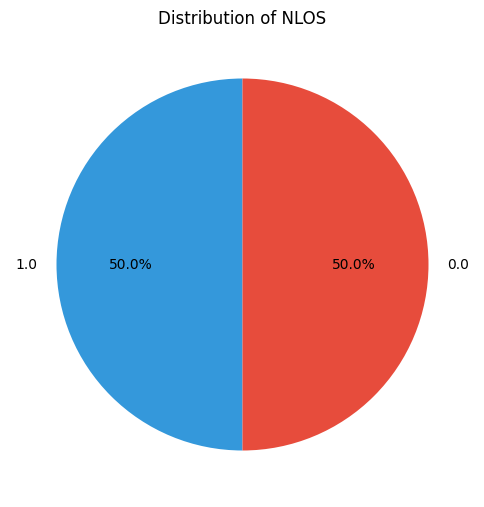

In [9]:
plt.figure(figsize=(6, 10))
count_NLOS.plot.pie(autopct="%1.1f%%", colors=["#3498db", "#e74c3c"], startangle=90)
plt.title("Distribution of NLOS")
plt.ylabel("")
plt.show()

##### **1.2.3 - Target Variable: FP_IDX**


**Identifying and Removing Outliers**

We be removing outliners Using IQR (Interquartile Range): 

1. Calculate IQR, Identify and Filter Outliers

In [10]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for FP_IDX
Q1 = df_clean["FP_IDX"].quantile(0.25)
Q3 = df_clean["FP_IDX"].quantile(0.75)

# Calculate the Interquartile Range (IQR)
IQR = Q3 - Q1

# Calculate lower and upper bounds for outliers
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers in FP_IDX based on the bounds
outliers = df_clean[
    (df_clean["FP_IDX"] < lower_bound) | (df_clean["FP_IDX"] > upper_bound)
]

# Print outliers
print("Outliers for 'FP_IDX':\n", outliers)

# Filter out outliers separately for LOS and NLOS
# For LOS (Line of Sight)
df_clean_filtered_LOS = df_clean[
    (df_clean["FP_IDX"] >= lower_bound)
    & (df_clean["FP_IDX"] <= upper_bound)
    & (df_clean["NLOS"] == 0.0)  # LOS condition
]

# For NLOS (Non-Line of Sight)
df_clean_filtered_NLOS = df_clean[
    (df_clean["FP_IDX"] >= lower_bound)
    & (df_clean["FP_IDX"] <= upper_bound)
    & (df_clean["NLOS"] == 1.0)  # NLOS condition
]

Outliers for 'FP_IDX':
        NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
26      1.0   4.54   737.0   2066.0   4232.0   3116.0         84.0   3789.0   
31      1.0   8.88   736.0   1823.0   1750.0   1277.0         76.0   4493.0   
46      1.0   5.86   737.0   3448.0   5723.0   3512.0         84.0    953.0   
49      1.0   7.32   734.0   2304.0   1919.0   1957.0         72.0   9314.0   
62      1.0  12.57   731.0   3438.0   1617.0   1713.0         76.0   1596.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41868   1.0   3.39   722.0    711.0   1391.0    829.0         88.0   2237.0   
41869   1.0   7.09   736.0   1501.0   1581.0    969.0         64.0    297.0   
41910   1.0   7.33   736.0    272.0   1719.0   1823.0         88.0   1561.0   
41969   1.0  13.13   727.0    719.0   1209.0   1395.0         88.0    924.0   
41982   1.0   4.64   733.0   1005.0   2047.0   1514.0         60.0    396.0   

       MAX_NOISE  RXPACC  .

2. Combine Data, Clean Redundant Columns, and Rename

In [11]:
# Combine both cleaned datasets (LOS and NLOS)
df_clean_filtered = pd.concat([df_clean_filtered_LOS, df_clean_filtered_NLOS])

# Remove redundant 'NLOS' column if it exists
if "category" in df_clean_filtered.columns and "NLOS" in df_clean_filtered.columns:
    df_clean_filtered = df_clean_filtered.drop(columns=["NLOS"])

# Rename 'NLOS' column to 'Signal_Path' if it exists
df_clean_filtered = (
    df_clean_filtered.rename(columns={"NLOS": "Signal_Path"})
    if "NLOS" in df_clean_filtered.columns
    else df_clean_filtered
)

After removing the outliners, next we will be filtering the dataset based on **FP_IDX** values within a specified range and adds a new **Category** column that labels the data as **"LOS"** or **"NLOS"** based on the NLOS values.

In [12]:
df_clean_filtered = df_clean[
    (df_clean["FP_IDX"] >= lower_bound) & (df_clean["FP_IDX"] <= upper_bound)
].copy()
# Create a new column to indicate the category (LOS or NLOS)
df_clean_filtered.loc[:, "Category"] = df_clean_filtered["NLOS"].apply(
    lambda x: "LOS" if x == 1.0 else "NLOS"
)

print(df_clean_filtered)

       NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
0       1.0   6.18   749.0   4889.0  13876.0  10464.0        240.0   9048.0   
1       1.0   4.54   741.0   2474.0   2002.0   1593.0         68.0   6514.0   
2       1.0   4.39   744.0   1934.0   2615.0   4114.0         52.0   2880.0   
3       1.0   1.27   748.0  16031.0  17712.0  10420.0         64.0  12855.0   
4       0.0   1.16   743.0  20070.0  19886.0  15727.0         76.0  11607.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41995   0.0   4.09   745.0   1106.0   6951.0   6283.0         88.0  10076.0   
41996   0.0   2.18   744.0  14870.0  13482.0   8864.0         44.0  12604.0   
41997   0.0   1.25   748.0  18329.0  17722.0  10731.0         60.0  10192.0   
41998   0.0   3.17   747.0   3654.0  18470.0  17737.0         64.0  12018.0   
41999   1.0   7.24   743.0  15428.0  16758.0  10250.0         60.0  17738.0   

       MAX_NOISE  RXPACC  ...  CIR1007  CIR1008  CI

**Data Vizualization**

The box plot below compares the distribution of **FP_IDX** values between **LOS** and **NLOS**. This helps in identifying differences in their statistical properties.

From the graph, we observe that **NLOS** has an outlier, indicating a potential anomaly, while **LOS** values are more evenly spread.

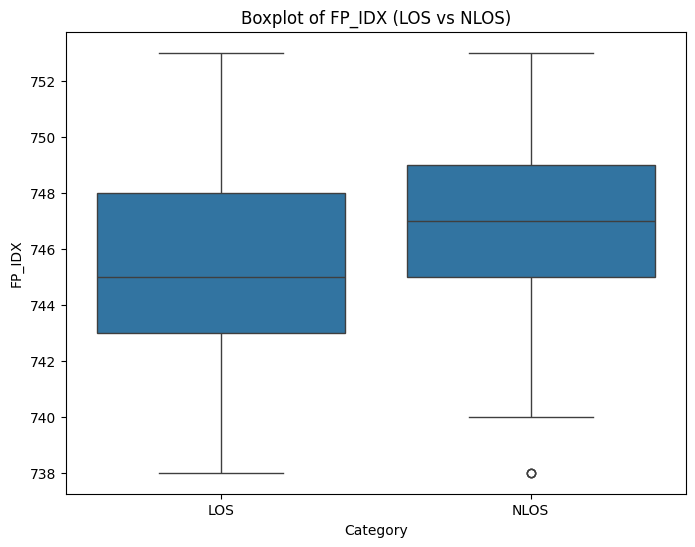

In [13]:
plt.figure(figsize=(8, 6))
sns.boxplot(x="Category", y="FP_IDX", data=df_clean_filtered)
plt.title("Boxplot of FP_IDX (LOS vs NLOS)")
plt.show()

##### **1.2.4 - Target Variable: FP_AMP1, FP_AMP2**, **FP_AMP3**

**Identifying and Removing Outliers**
We be removing outliners Using IQR (Interquartile Range): 

For FP_AMP1, 

In [14]:
# Calculate the Range using IQR for FP_AMP1
Q1_FP_AMP1 = df_clean["FP_AMP1"].quantile(0.25)
Q3_FP_AMP1 = df_clean["FP_AMP1"].quantile(0.75)
IQR_FP_AMP1 = Q3_FP_AMP1 - Q1_FP_AMP1
lower_bound_FP_AMP1 = Q1_FP_AMP1 - 1.5 * IQR_FP_AMP1
upper_bound_FP_AMP1 = Q3_FP_AMP1 + 1.5 * IQR_FP_AMP1

# Identify outliers
outliers_FP_AMP1 = df_clean[
    (df_clean["FP_AMP1"] < lower_bound_FP_AMP1)
    | (df_clean["FP_AMP1"] > upper_bound_FP_AMP1)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_FP_AMP1 = df_clean[
    (df_clean["FP_AMP1"] >= lower_bound_FP_AMP1)
    & (df_clean["FP_AMP1"] <= upper_bound_FP_AMP1)
]

# Print outliers
print("Outliers for 'FP_AMP1':\n", outliers_FP_AMP1)

Outliers for 'FP_AMP1':
 Empty DataFrame
Columns: [NLOS, RANGE, FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3, STDEV_NOISE, CIR_PWR, MAX_NOISE, RXPACC, CH, FRAME_LEN, PREAM_LEN, BITRATE, PRFR, CIR0, CIR1, CIR2, CIR3, CIR4, CIR5, CIR6, CIR7, CIR8, CIR9, CIR10, CIR11, CIR12, CIR13, CIR14, CIR15, CIR16, CIR17, CIR18, CIR19, CIR20, CIR21, CIR22, CIR23, CIR24, CIR25, CIR26, CIR27, CIR28, CIR29, CIR30, CIR31, CIR32, CIR33, CIR34, CIR35, CIR36, CIR37, CIR38, CIR39, CIR40, CIR41, CIR42, CIR43, CIR44, CIR45, CIR46, CIR47, CIR48, CIR49, CIR50, CIR51, CIR52, CIR53, CIR54, CIR55, CIR56, CIR57, CIR58, CIR59, CIR60, CIR61, CIR62, CIR63, CIR64, CIR65, CIR66, CIR67, CIR68, CIR69, CIR70, CIR71, CIR72, CIR73, CIR74, CIR75, CIR76, CIR77, CIR78, CIR79, CIR80, CIR81, CIR82, CIR83, CIR84, ...]
Index: []

[0 rows x 1031 columns]


For FP_AMP2 ,

In [15]:
# Calculate the Range using IQR for FP_AMP2
Q1_FP_AMP2 = df_clean["FP_AMP2"].quantile(0.25)
Q3_FP_AMP2 = df_clean["FP_AMP2"].quantile(0.75)
IQR_FP_AMP2 = Q3_FP_AMP2 - Q1_FP_AMP2
lower_bound_FP_AMP2 = Q1_FP_AMP2 - 1.5 * IQR_FP_AMP2
upper_bound_FP_AMP2 = Q1_FP_AMP2 + 1.5 * IQR_FP_AMP2

# Identify outliers
outliers_FP_AMP2 = df_clean[
    (df_clean["FP_AMP2"] < lower_bound_FP_AMP2)
    | (df_clean["FP_AMP2"] > upper_bound_FP_AMP2)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_FP_AMP2 = df_clean[
    (df_clean["FP_AMP2"] >= lower_bound_FP_AMP2)
    & (df_clean["FP_AMP2"] <= upper_bound_FP_AMP2)
]

# Print outliers
print("Outliers for 'FP_AMP2':\n", outliers_FP_AMP2)

Outliers for 'FP_AMP2':
 Empty DataFrame
Columns: [NLOS, RANGE, FP_IDX, FP_AMP1, FP_AMP2, FP_AMP3, STDEV_NOISE, CIR_PWR, MAX_NOISE, RXPACC, CH, FRAME_LEN, PREAM_LEN, BITRATE, PRFR, CIR0, CIR1, CIR2, CIR3, CIR4, CIR5, CIR6, CIR7, CIR8, CIR9, CIR10, CIR11, CIR12, CIR13, CIR14, CIR15, CIR16, CIR17, CIR18, CIR19, CIR20, CIR21, CIR22, CIR23, CIR24, CIR25, CIR26, CIR27, CIR28, CIR29, CIR30, CIR31, CIR32, CIR33, CIR34, CIR35, CIR36, CIR37, CIR38, CIR39, CIR40, CIR41, CIR42, CIR43, CIR44, CIR45, CIR46, CIR47, CIR48, CIR49, CIR50, CIR51, CIR52, CIR53, CIR54, CIR55, CIR56, CIR57, CIR58, CIR59, CIR60, CIR61, CIR62, CIR63, CIR64, CIR65, CIR66, CIR67, CIR68, CIR69, CIR70, CIR71, CIR72, CIR73, CIR74, CIR75, CIR76, CIR77, CIR78, CIR79, CIR80, CIR81, CIR82, CIR83, CIR84, ...]
Index: []

[0 rows x 1031 columns]


For FP_AMP3 ,

In [16]:
# Calculate the Range using IQR for FP_AMP3
Q1_FP_AMP3 = df_clean["FP_AMP3"].quantile(0.25)
Q3_FP_AMP3 = df_clean["FP_AMP3"].quantile(0.75)
IQR_FP_AMP3 = Q3_FP_AMP3 - Q1_FP_AMP3
lower_bound_FP_AMP3 = Q1_FP_AMP3 - 1.5 * IQR_FP_AMP3
upper_bound_FP_AMP3 = Q1_FP_AMP3 + 1.5 * IQR_FP_AMP3

# Identify outliers
outliers_FP_AMP3 = df_clean[
    (df_clean["FP_AMP3"] < lower_bound_FP_AMP3)
    | (df_clean["FP_AMP3"] > upper_bound_FP_AMP3)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_FP_AMP3 = df_clean[
    (df_clean["FP_AMP3"] >= lower_bound_FP_AMP3)
    & (df_clean["FP_AMP3"] <= upper_bound_FP_AMP3)
]

# Print outliers
print("Outliers for 'FP_IDX':\n", outliers_FP_AMP3)

Outliers for 'FP_IDX':
        NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
104     0.0   5.08   745.0   2922.0  15891.0  19129.0         80.0   9962.0   
123     0.0   1.40   750.0  16026.0  20343.0  19026.0         52.0  12543.0   
145     0.0   5.69   746.0   4278.0  17974.0  20245.0         48.0   9526.0   
185     0.0   1.98   746.0  12539.0  20207.0  19131.0         52.0  15467.0   
365     1.0   6.91   746.0   2318.0  19454.0  20296.0         60.0  23903.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41757   1.0   0.54   751.0   7203.0  19603.0  19507.0        160.0  11759.0   
41829   0.0   4.74   748.0   9000.0  15539.0  19426.0         68.0  10231.0   
41843   0.0   3.47   744.0   7574.0  19104.0  20218.0         52.0  11691.0   
41904   0.0   2.05   749.0   7766.0  18756.0  19044.0         60.0   9430.0   
41953   0.0   0.98   745.0  12354.0  11519.0  19650.0         48.0  15739.0   

       MAX_NOISE  RXPACC  .

After removing the outliers, we combine FP_AMP1, FP_AMP2, and FP_AMP3 into one DataFrame

In [17]:
# Combining multiplte dataframe in to one DataFrame
df_filtered = pd.DataFrame(
    {
        "FP_AMP1": df_clean_filtered_FP_AMP1["FP_AMP1"],
        "FP_AMP2": df_clean_filtered_FP_AMP2["FP_AMP2"],
        "FP_AMP3": df_clean_filtered_FP_AMP3["FP_AMP3"],
    }
)

# Reshape the data for the violin plot
df_filtered_melted = df_filtered.melt(var_name="Feature", value_name="Value")

**Data Vizualization**

After combining all into one DataFrame, we will plot a **violin graph** to illustrate the spread and median of **FP_AMP1**, **FP_AMP2**, and **FP_AMP3**, as their ranges are similar.

From the graph, we can see that these features have similar ranges, spread, and median. However, the median and spread for **FP_AMP1** are slightly higher than those of **FP_AMP2** and **FP_AMP3**, suggesting that **FP_AMP1** has slightly more variation or a higher central tendency compared to the other two.

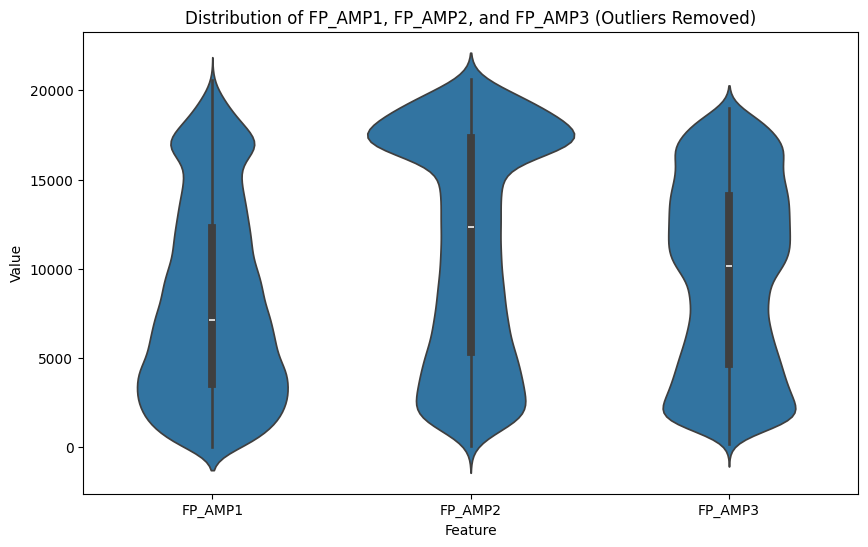

In [18]:
plt.figure(figsize=(10, 6))
sns.violinplot(x="Feature", y="Value", data=df_filtered_melted)

plt.title("Distribution of FP_AMP1, FP_AMP2, and FP_AMP3 (Outliers Removed)")
plt.show()

##### **1.2.5 - Target Variable: STDEV_NOISE**


For **STDEV_NOISE**, we will plot a strip plot to gain a better understanding of the distribution. The strip plot below illustrates the distribution of **STDEV_NOISE** with labels 0.0 and 1.0.

From the graph, we can observe that the 0.0 label has a lower **STDEV_NOISE** value compared to 1.0, indicating that the noise is more consistent in **LOS** (Line-of-Sight) than in **NLOS** (Non-Line-of-Sight).

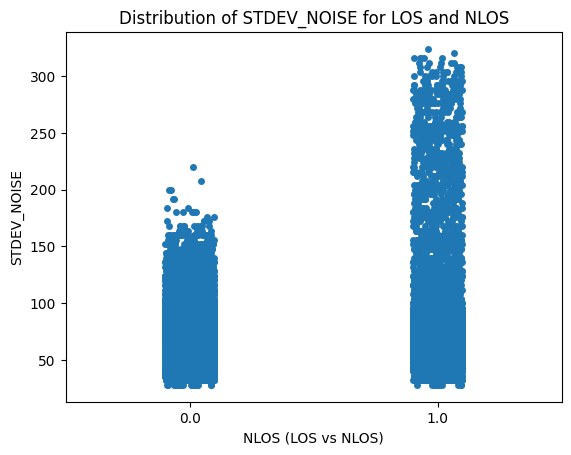

In [19]:
sns.stripplot(data=df_clean, x="NLOS", y="STDEV_NOISE", jitter=True)
plt.title("Distribution of STDEV_NOISE for LOS and NLOS")
plt.xlabel("NLOS (LOS vs NLOS)")
plt.ylabel("STDEV_NOISE")
plt.show()

##### **1.2.6 - Target Variable: CIR_PWR**

**Identifying and Removing Outliers**

We be removing outliners Using IQR (Interquartile Range): 

1. Calculate IQR and Identify Outliers

In [20]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for CIR_PWR
Q1_CIR_PWR = df_clean["CIR_PWR"].quantile(0.25)
Q3_CIR_PWR = df_clean["CIR_PWR"].quantile(0.75)

# Calculate the Interquartile Range (IQR) for CIR_PWR
IQR_CIR_PWR = Q3_CIR_PWR - Q1_CIR_PWR

# Calculate lower and upper bounds for outliers
lower_bound_CIR_PWR = Q1_CIR_PWR - 1.5 * IQR_CIR_PWR
upper_bound_CIR_PWR = Q3_CIR_PWR + 1.5 * IQR_CIR_PWR

# Identify outliers in CIR_PWR based on the calculated bounds
outliers_CIR_PWR = df_clean[
    (df_clean["CIR_PWR"] < lower_bound_CIR_PWR)
    | (df_clean["CIR_PWR"] > upper_bound_CIR_PWR)
]

2. Filter and Clean Data

In [21]:
# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_CIR_PWR = df_clean[
    (df_clean["CIR_PWR"] >= lower_bound_CIR_PWR)
    & (df_clean["CIR_PWR"] <= upper_bound_CIR_PWR)
]

# Print outliers
print("Outliers for 'CIR_PWR':\n", outliers_CIR_PWR)

Outliers for 'CIR_PWR':
        NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
34      1.0   6.35   746.0  11146.0  10502.0   6624.0         60.0  21115.0   
56      0.0   2.12   747.0  13091.0  16349.0  11204.0        120.0  29570.0   
67      1.0   6.31   750.0  13805.0  19543.0  11380.0         64.0  31759.0   
71      1.0   6.68   745.0  13068.0   9016.0   5174.0         68.0  23124.0   
75      0.0   5.96   748.0  12532.0   8788.0  15810.0        128.0  25006.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41748   1.0   7.64   744.0    248.0  14006.0  12489.0         64.0  22825.0   
41834   0.0   5.09   750.0   8443.0  16866.0  11160.0         68.0  21287.0   
41871   0.0   3.07   746.0   5715.0  10261.0  12889.0         84.0  29942.0   
41922   0.0   1.67   746.0  10780.0  18043.0  14167.0        136.0  26737.0   
41974   1.0   7.59   747.0    108.0  17802.0  17768.0         52.0  24454.0   

       MAX_NOISE  RXPACC  

**Data Vizualization**

After removing the outliers, we will plot a histogram to better understand the distribution of **CIR_PWER** values. T

The histogram below illustrates the spread of values for **CIR_PWER** with labels 0.0 and 1.0. Based on this graph, we can see that the distributions for XLOS and NLOS statuses are similar for **CIR_PWER**, but **NLOS** has a wider spread of values.

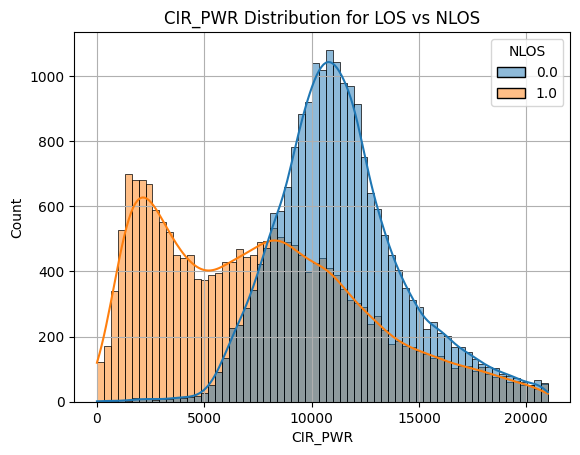

In [22]:
sns.histplot(data=df_clean_filtered_CIR_PWR, x="CIR_PWR", hue="NLOS", kde=True)
plt.title("CIR_PWR Distribution for LOS vs NLOS")
plt.xlabel("CIR_PWR")
plt.ylabel("Count")
plt.grid(True)
plt.show()

##### **1.2.7 - Target Variable: MAX_NOISE**

For **MAX_NOISE**, we will plot a violin plot to better understand the distribution and observe the variation in noise. The plot below illustrates the distribution of MAX_NOISE with labels 0.0 and 1.0.

From the graph, we can observe how the noise varies between LOS (Line-of-Sight) and NLOS (Non-Line-of-Sight), highlighting the differences in their noise patterns.

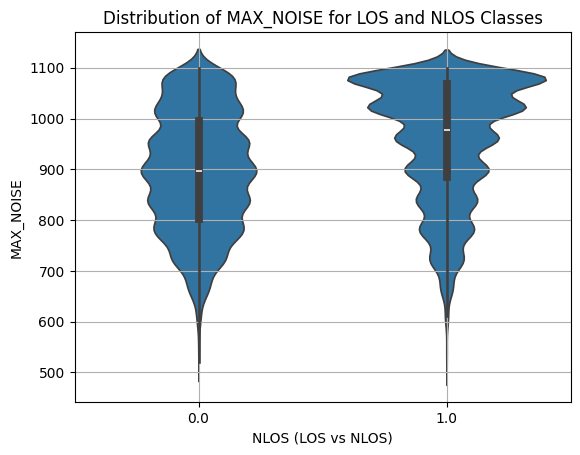

In [23]:
df_clean_filtered = df_clean[
    (df_clean["MAX_NOISE"] >= 500) & (df_clean["MAX_NOISE"] < 1100)
]

sns.violinplot(data=df_clean_filtered, x="NLOS", y="MAX_NOISE")
plt.title("Distribution of MAX_NOISE for LOS and NLOS Classes")
plt.xlabel("NLOS (LOS vs NLOS)")
plt.ylabel("MAX_NOISE")
plt.grid(True)
plt.show()

##### **1.2.8 - Target Variable: RXPACC**

**Identifying and Removing Outliers**
We be removing outliners Using IQR (Interquartile Range): 

Identify Outliers Using IQR for RXPACC

In [24]:
# Filter the data based on specific RXPACC values (between 500 and 1100)
df_clean_filtered_RXPACC = df_clean[
    (df_clean["RXPACC"] >= 500) & (df_clean["RXPACC"] < 1100)
]

print(df_clean_filtered_RXPACC)

       NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
0       1.0   6.18   749.0   4889.0  13876.0  10464.0        240.0   9048.0   
1       1.0   4.54   741.0   2474.0   2002.0   1593.0         68.0   6514.0   
2       1.0   4.39   744.0   1934.0   2615.0   4114.0         52.0   2880.0   
5       1.0   5.04   743.0   6490.0  12580.0   9741.0         92.0   3870.0   
6       1.0   4.82   750.0   9569.0  14115.0   9875.0         76.0  10179.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41985   1.0   3.22   746.0     35.0  12454.0  16598.0         80.0  11674.0   
41989   1.0   6.95   745.0   7356.0   7367.0   5727.0         64.0   3491.0   
41993   0.0   3.62   750.0   7650.0   8469.0   8684.0         64.0   9906.0   
41994   1.0   5.16   742.0   3132.0   3137.0   1868.0         76.0   3573.0   
41998   0.0   3.17   747.0   3654.0  18470.0  17737.0         64.0  12018.0   

       MAX_NOISE  RXPACC  ...  CIR1006  CIR1007  CI

Next, we will remove columns that are not necessary for plotting the graph. This will help streamline the dataset, ensuring that we only work with the relevant features needed for visualization.

In [25]:
# List of columns to exclude
columns_to_exclude = [
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "CIR_PWR",
    "MAX_NOISE",
]

# Remove the CIR_[Number] columns using regex
columns_to_exclude += [
    col for col in df_clean_filtered_RXPACC.columns if col.startswith("CIR")
]
df_clean_copy = df_clean_filtered_RXPACC.drop(columns=columns_to_exclude)


print(df_clean_copy)

       NLOS  RANGE  STDEV_NOISE  RXPACC   CH  FRAME_LEN  PREAM_LEN  BITRATE  \
0       1.0   6.18        240.0  1024.0  2.0       39.0     1024.0    110.0   
1       1.0   4.54         68.0  1024.0  2.0       39.0     1024.0    110.0   
2       1.0   4.39         52.0  1024.0  2.0       27.0     1024.0    110.0   
5       1.0   5.04         92.0  1024.0  2.0       39.0     1024.0    110.0   
6       1.0   4.82         76.0  1024.0  2.0       39.0     1024.0    110.0   
...     ...    ...          ...     ...  ...        ...        ...      ...   
41985   1.0   3.22         80.0  1024.0  2.0       27.0     1024.0    110.0   
41989   1.0   6.95         64.0  1024.0  2.0       27.0     1024.0    110.0   
41993   0.0   3.62         64.0   707.0  2.0       39.0     1024.0    110.0   
41994   1.0   5.16         76.0  1024.0  2.0       39.0     1024.0    110.0   
41998   0.0   3.17         64.0   789.0  2.0       39.0     1024.0    110.0   

       PRFR  
0      64.0  
1      64.0  
2      64

**Data Vizualization**

For **RXPACC** , we will plot a **KDE plot** to compare the distribution of **RXPACC** for **LOS (0.0)** and **NLOS (1.0)** classes. The plot helps highlight the density of **RXPACC** values, making it easy to spot any differences.

From the graph, we can see that **NLOS** has a more concentrated distribution of **RXPACC** values, while **LOS** shows a wider spread.

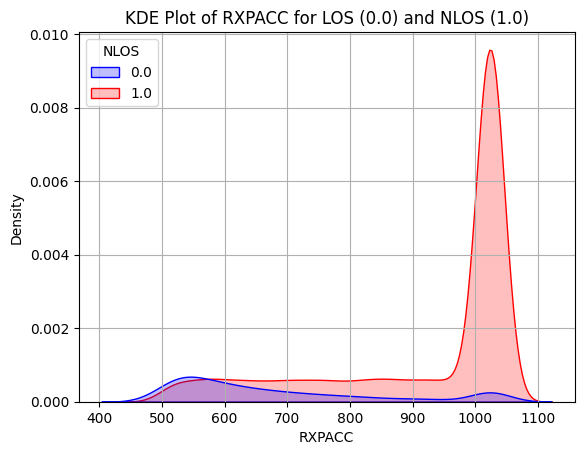

In [26]:
sns.kdeplot(
    data=df_clean_copy, x="RXPACC", hue="NLOS", fill=True, palette={0: "blue", 1: "red"}
)
plt.title("KDE Plot of RXPACC for LOS (0.0) and NLOS (1.0)")
plt.xlabel("RXPACC")
plt.ylabel("Density")
plt.grid(True)
plt.show()

##### **1.2.9 - Target Variable: FRAME_LEN**

**Count Occurrences of Values**

In [27]:
count_framelen = df_clean["FRAME_LEN"].value_counts()
print(count_framelen)

FRAME_LEN
39.0    23806
27.0    18193
29.0        1
Name: count, dtype: int64


**Data Visualization**

For **FRAME_LEN**, we will plot a bar chart showing the count distribution, which allows us to see how the values are spread across the dataset.

From this graph, we can observe that **39.0** appears the most frequently, followed by **27.0**, with **29.0** being very rare in the dataset.`

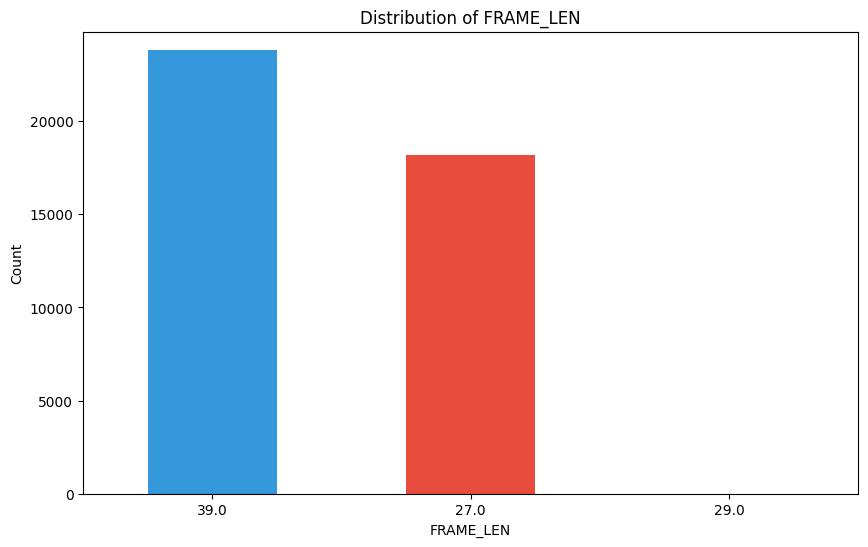

In [28]:
plt.figure(figsize=(10, 6))
count_framelen.plot.bar(color=["#3498db", "#e74c3c", "#f39c12"])
plt.title("Distribution of FRAME_LEN")
plt.ylabel("Count")
plt.xlabel("FRAME_LEN")
plt.xticks(rotation=0)

plt.yscale("linear")
plt.ylim(0, count_framelen.max() + 1000)

plt.show()

##### **1.2.10 - Target Variable: PREAM_LEN**

**Count Occurrences of Values**

In [29]:
count_PREAM_LEN = df_clean["PREAM_LEN"].value_counts()
print(count_PREAM_LEN)

PREAM_LEN
1024.0    40443
1536.0     1557
Name: count, dtype: int64


**Data Vizualization**

For **PREAM_LEN**, we will plot a bar chart showing the count distribution, which allows us to see how the values are spread across the dataset.

From this graph, we can observe that **1024.0** is overwhelmingly more common than **1536.0**, with **1024.0** making up the vast majority of the dataset.

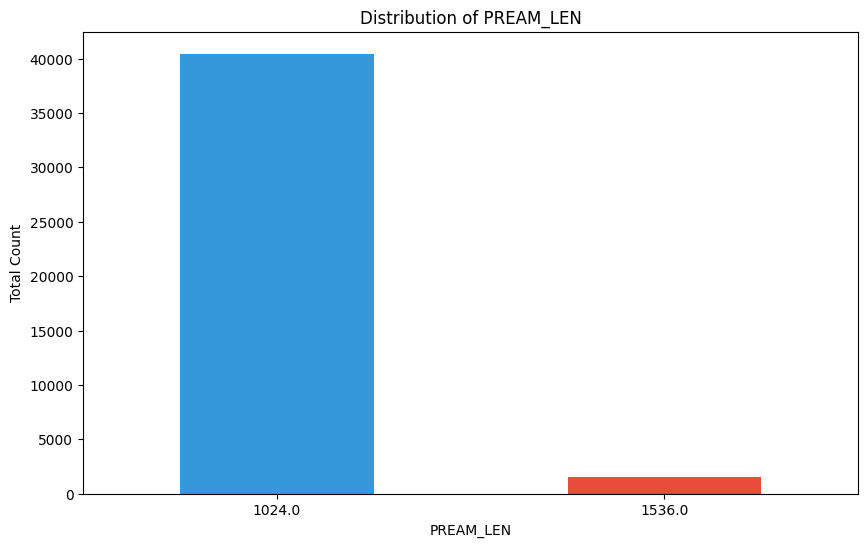

In [30]:
plt.figure(figsize=(10, 6))
count_PREAM_LEN.plot.bar(color=["#3498db", "#e74c3c"])
plt.title("Distribution of PREAM_LEN")
plt.ylabel("Total Count")
plt.xticks(rotation=0)
plt.show()

##### **1.2.1.11 - Target Variable: PRFR and BITRATE**

**Count Occurrences of Values**

In [31]:
# For 'PRFR' values
count_PRFR = df_clean["PRFR"].value_counts()

# For 'BITRATE' values
count_BITRATE = df_clean["BITRATE"].value_counts()

**Data Vizualization**

Combine and Plot the Distribution of 'PRFR' and 'BITRATE'

After counting the Occurense for PRFR and BITRATE, the graph will display side-by-side bars showing their total count occurrences. Since the columns have fixed categories, the graph will provide a clear comparison of how each category in PRFR and BITRATE is distributed.

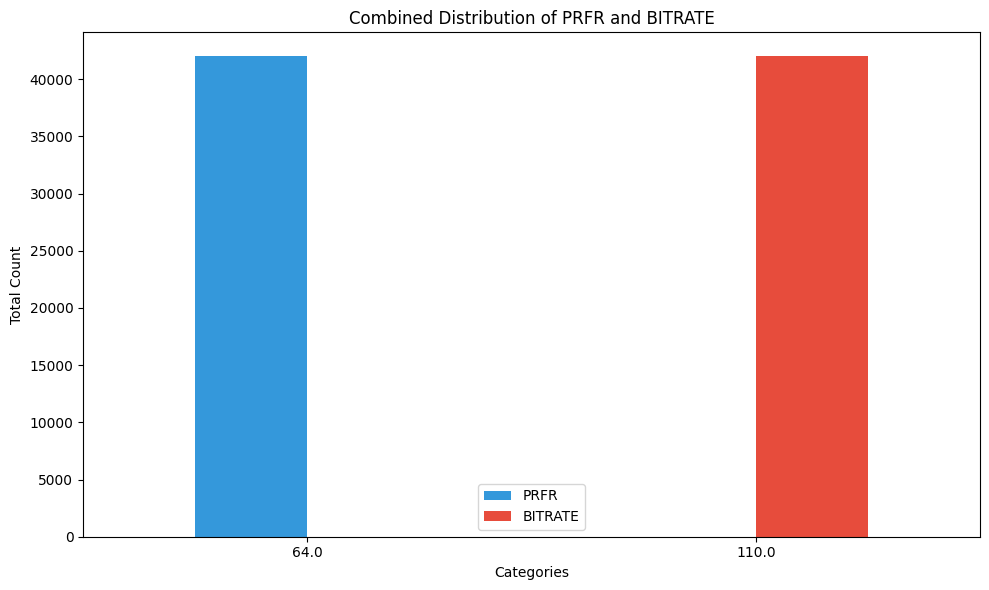

In [32]:
combined_df = pd.DataFrame(
    {"PRFR": count_PRFR, "BITRATE": count_BITRATE, "BITRATE": count_BITRATE}
).fillna(
    0
)  # combine

combined_df.plot(kind="bar", figsize=(10, 6), color=["#3498db", "#e74c3c"])

plt.title("Combined Distribution of PRFR and BITRATE")
plt.ylabel("Total Count")
plt.xlabel("Categories")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

##### **1.2.1.12 - Target Variable: RANGE**

**Identifying and Removing Outliers**

We be removing outliners Using IQR (Interquartile Range): 

In [33]:
Q1_RANGE = df_clean["RANGE"].quantile(0.25)
Q3_RANGE = df_clean["RANGE"].quantile(0.75)
IQR_RANGE = Q3_RANGE - Q1_RANGE
lower_bound_RANGE = Q1_RANGE - 1.5 * IQR_RANGE
upper_bound_RANGE = Q3_RANGE + 1.5 * IQR_RANGE

# Identify outliers
outliers_RANGE = df_clean[
    (df_clean["RANGE"] < lower_bound_RANGE) | (df_clean["RANGE"] > upper_bound_RANGE)
]

# Filter out outliers based on the calculated bounds using IQR method
df_clean_filtered_RANGE = df_clean[
    (df_clean["RANGE"] >= lower_bound_RANGE) & (df_clean["RANGE"] <= upper_bound_RANGE)
]

print(df_clean_filtered_RANGE)

       NLOS  RANGE  FP_IDX  FP_AMP1  FP_AMP2  FP_AMP3  STDEV_NOISE  CIR_PWR  \
0       1.0   6.18   749.0   4889.0  13876.0  10464.0        240.0   9048.0   
1       1.0   4.54   741.0   2474.0   2002.0   1593.0         68.0   6514.0   
2       1.0   4.39   744.0   1934.0   2615.0   4114.0         52.0   2880.0   
3       1.0   1.27   748.0  16031.0  17712.0  10420.0         64.0  12855.0   
4       0.0   1.16   743.0  20070.0  19886.0  15727.0         76.0  11607.0   
...     ...    ...     ...      ...      ...      ...          ...      ...   
41995   0.0   4.09   745.0   1106.0   6951.0   6283.0         88.0  10076.0   
41996   0.0   2.18   744.0  14870.0  13482.0   8864.0         44.0  12604.0   
41997   0.0   1.25   748.0  18329.0  17722.0  10731.0         60.0  10192.0   
41998   0.0   3.17   747.0   3654.0  18470.0  17737.0         64.0  12018.0   
41999   1.0   7.24   743.0  15428.0  16758.0  10250.0         60.0  17738.0   

       MAX_NOISE  RXPACC  ...  CIR1006  CIR1007  CI

**Data Vizualization**

For **RANGE**, we will plot a box plot to understand its distribution and identify outliers. 

From the graph, we can observe that **RANGE** has a wide spread with some potential outliers at the higher end.

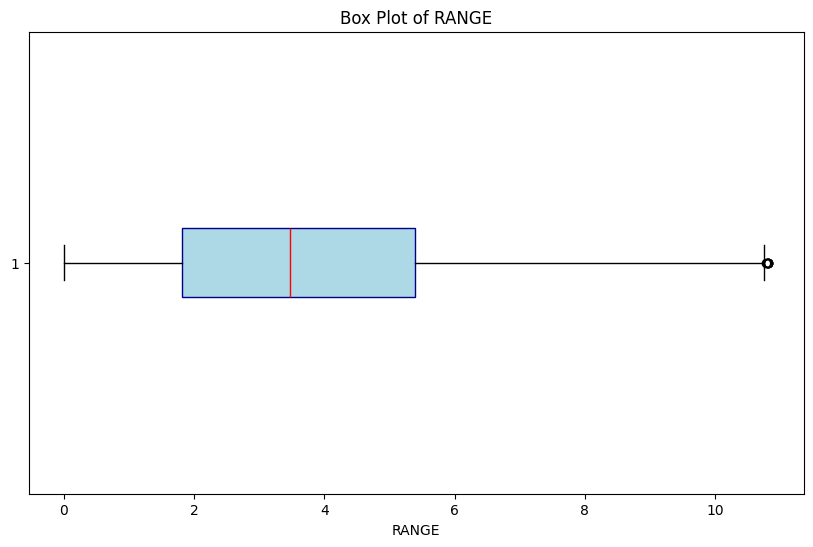

In [34]:
plt.figure(figsize=(10, 6))
plt.boxplot(
    df_clean_filtered_RANGE["RANGE"],
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="lightblue", color="darkblue"),
    medianprops=dict(color="red"),
)
plt.title("Box Plot of RANGE")
plt.xlabel("RANGE")
plt.show()

#### **1.3 - Feature Evaluation and Relationship Analysis**

##### **1.3.1 -Feature Evaluation and Preprocessing**

In this section, we focus on essential techniques for preparing and evaluating features in the dataset to ensure optimal model performance. These methods include understanding feature relationships through a correlation matrix, assessing the importance of features using mutual information, scaling data via normalization, and reducing dimensionality with Principal Component Analysis (PCA). These steps help refine the data for more accurate predictions and improve the overall efficiency of the machine learning model.

###### **1.3.1.1 - Correlation Matrix**

The correlation matrix is computed for a selected set of features, including `RANGE`, `FP_IDX`, `FP_AMP1`, `FP_AMP2`, `FP_AMP3`, `STDEV_NOISE`, `CIR_PWR`, `MAX_NOISE`, `RXPACC`, `FRAME_LEN`, and `PREAM_LEN`. Pearson's correlation coefficient is used to measure the linear relationships between each pair of features, providing valuable insights into how they are related and the potential for multicollinearity in the dataset.

In [35]:
features = [
    "RANGE",
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "STDEV_NOISE",
    "CIR_PWR",
    "MAX_NOISE",
    "RXPACC",
    "FRAME_LEN",
    "PREAM_LEN",
]

correlation_matrix = df_clean[features].corr()
print(correlation_matrix)

                RANGE    FP_IDX   FP_AMP1   FP_AMP2   FP_AMP3  STDEV_NOISE  \
RANGE        1.000000 -0.321809 -0.459196 -0.479689 -0.459521     0.089544   
FP_IDX      -0.321809  1.000000  0.318126  0.442985  0.460630    -0.040994   
FP_AMP1     -0.459196  0.318126  1.000000  0.594008  0.459750    -0.058817   
FP_AMP2     -0.479689  0.442985  0.594008  1.000000  0.886110    -0.099765   
FP_AMP3     -0.459521  0.460630  0.459750  0.886110  1.000000    -0.084635   
STDEV_NOISE  0.089544 -0.040994 -0.058817 -0.099765 -0.084635     1.000000   
CIR_PWR     -0.263718  0.316600  0.341158  0.394945  0.400304    -0.033533   
MAX_NOISE   -0.260065  0.106560  0.235854  0.194410  0.184564     0.828995   
RXPACC       0.626349 -0.382566 -0.529544 -0.622441 -0.594305     0.240308   
FRAME_LEN   -0.048082  0.000497 -0.004481 -0.000681 -0.000004    -0.050907   
PREAM_LEN    0.390055 -0.229423 -0.171689 -0.221676 -0.215839     0.087069   

              CIR_PWR  MAX_NOISE    RXPACC  FRAME_LEN  PREAM_LE

**Result and Data Visualization**

The heatmap visually represents the correlation matrix, where the intensity of the color indicates the strength of the correlation between pairs of features. Darker colors represent higher correlations, either positive or negative.

From the correlation matrix and heatmap, we can observe several key relationships:
- `RXPACC` shows a strong positive correlation with `RANGE` (0.63), indicating that `RXPACC` is highly relevant for predicting `RANGE`.
- There is a notable negative correlation between `RANGE` and features like `FP_AMP1`, `FP_AMP2`, and `FP_AMP3` (around -0.46 to -0.48), suggesting an inverse relationship.
- Highly correlated features such as `FP_AMP2` and `FP_AMP3` (0.89) imply that they carry similar information, which could lead to redundancy in the model.
- Features like `FRAME_LEN` and `STDEV_NOISE` show low correlations with `RANGE`, suggesting that they may be less informative for predicting the target variable.

The heatmap provides an effective visual tool for quickly identifying these relationships, guiding feature selection, and helping avoid multicollinearity issues during model training.

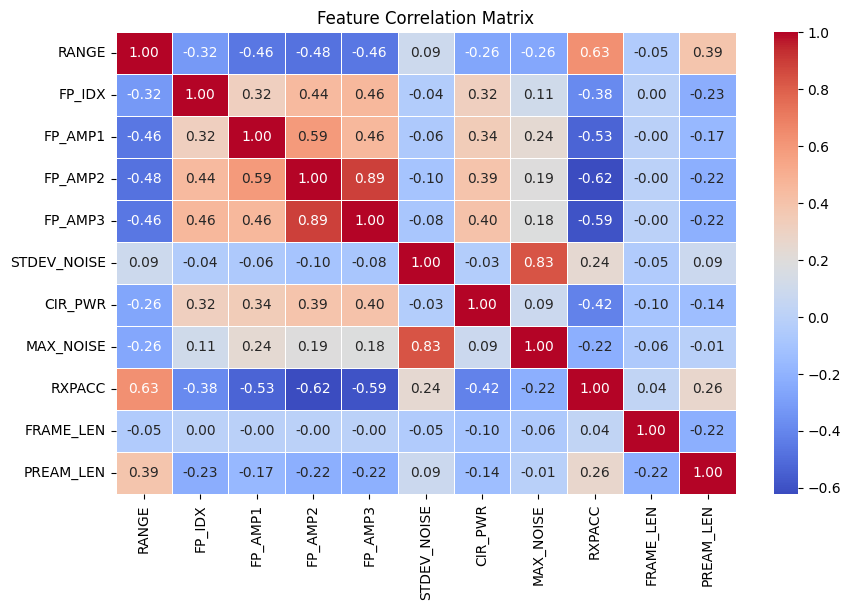

In [36]:
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

**Summary**

In summary, the correlation matrix reveals key relationships, with `RXPACC` being the most relevant predictor for `RANGE`. At the same time, highly correlated features like `FP_AMP1`, `FP_AMP2`, and `FP_AMP3` may introduce redundancy, suggesting the need for careful feature selection to optimize the model's performance.

###### **1.3.1.2 - Mutual Information**

Mutual Information (MI) is an effective algorithm for measuring the dependency between a feature and the target variable. It quantifies how much knowing the value of a feature reduces uncertainty about the target variable. In this case, we used the `mutual_info_regression` function from `sklearn` to calculate MI scores between each feature and the target variable (`RANGE`). By calculating these scores, we can identify which features have the most significant influence on predicting the target.

In [37]:
# import libraries
try:
    from sklearn.feature_selection import mutual_info_regression

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


In [38]:
# mutual information => (to check the relationship between the features)

# Features
features = [
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "STDEV_NOISE",
    "CIR_PWR",
    "MAX_NOISE",
    "RXPACC",
    "FRAME_LEN",
    "PREAM_LEN",
]

# Define X as features set
X = df_clean[features]

# Define target variable
y = df_clean["RANGE"]

# Compute mutual information scores
mi_scores = mutual_info_regression(X, y)
mi_scores = pd.Series(mi_scores, index=features)

# Sort the scores in descending order and print
mi_scores = mi_scores.sort_values(ascending=False)
print("Mutual Information Scores (in descending order):")
print(mi_scores)

Mutual Information Scores (in descending order):
RXPACC         0.378967
MAX_NOISE      0.218276
CIR_PWR        0.180688
FP_AMP2        0.151898
FP_AMP1        0.150084
FP_AMP3        0.137403
STDEV_NOISE    0.113730
FP_IDX         0.086237
PREAM_LEN      0.078017
FRAME_LEN      0.009111
dtype: float64


**Result and Data Visualization**

The MI scores represent how much information each feature provides in predicting the target variable, `RANGE`. Features with higher MI scores are more relevant for the prediction task. After calculating the MI scores, we obtain the following rankings:

- `RXPACC` has the highest MI score (0.381572), indicating it is the most influential feature in predicting `RANGE`.
- `MAX_NOISE` (0.217779) and `CIR_PWR` (0.180787) also have relatively high MI scores, suggesting they contribute significantly to the prediction of `RANGE`.
- Features like `FRAME_LEN` (0.004204) show very low MI scores, implying that they have minimal impact on predicting the target variable.

The bar plot visually represents these MI scores, where each bar's height corresponds to the importance of the respective feature in predicting `RANGE`. The graph provides a clear view of the feature importance, making it easier to understand which features should be prioritized for model training.

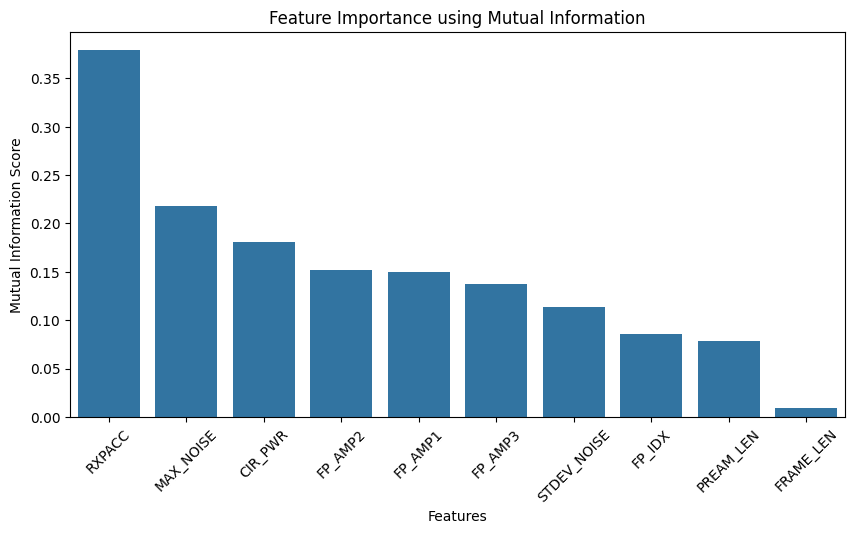

In [39]:
plt.figure(figsize=(10, 5))
sns.barplot(x=mi_scores.index, y=mi_scores.values)
plt.xlabel("Features")
plt.ylabel("Mutual Information Score")
plt.title("Feature Importance using Mutual Information")
plt.xticks(rotation=45)
plt.show()

**Summary**

In summary, `RXPACC` emerges as the most important feature for predicting `RANGE`, with high MI scores for other features like `MAX_NOISE` and `CIR_PWR`. The visualization highlights the importance of selecting the most informative features while disregarding those with low MI scores, such as `FRAME_LEN`, to avoid overcomplicating the model.

###### **1.3.1.3 - Normalization**

Normalization is an important preprocessing step that ensures all features contribute equally to model training, particularly when the features are on different scales. In this case, MinMaxScaler is applied to scale the features into the range [0, 1]. This transformation is particularly crucial for models that rely on distances or gradients, such as K-Nearest Neighbors (KNN), Support Vector Machines (SVM), and neural networks.


In [40]:
# import libraries

try:
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import MinMaxScaler

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


In [41]:
# Select features and target variable
X = df_clean.drop(columns=["NLOS"])  # Assuming 'NLOS' is the target variable
y = df_clean["NLOS"]

# Apply MinMaxScaler to normalize the features
scaler = MinMaxScaler()

# Fit the scaler to the entire dataset (X) and transform the features
X_scaled = scaler.fit_transform(X)

# Convert the scaled data back to DataFrame with the same column names
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split the data into training and testing sets (after normalization)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# Verify the scaled data
print(X_train.head())

          RANGE    FP_IDX   FP_AMP1   FP_AMP2   FP_AMP3  STDEV_NOISE  \
34941  0.125981  0.248227  0.113348  0.178834  0.116969     0.135135   
24433  0.126338  0.290780  0.328228  0.344828  0.291515     0.108108   
24432  0.140971  0.248227  0.114466  0.084189  0.048455     0.175676   
8832   0.038901  0.290780  0.141503  0.208210  0.108583     0.108108   
30291  0.049607  0.297872  0.358230  0.499976  0.354389     0.094595   

        CIR_PWR  MAX_NOISE    RXPACC   CH  ...   CIR1006   CIR1007   CIR1008  \
34941  0.184396   0.150854  0.965517  0.0  ...  0.188442  0.183155  0.383959   
24433  0.296253   0.118749  0.357759  0.0  ...  0.113065  0.107620  0.181741   
24432  0.041066   0.182136  0.896552  0.0  ...  0.167085  0.052139  0.191126   
8832   0.245780   0.119778  0.567888  0.0  ...  0.067839  0.221925  0.225256   
30291  0.361105   0.152912  0.251078  0.0  ...  0.131281  0.169786  0.290102   

        CIR1009   CIR1010   CIR1011   CIR1012   CIR1013   CIR1014  CIR1015  
34941  0.

**Result and Data Visualization**

After applying the MinMaxScaler, all features in the dataset are now scaled to the [0, 1] range. Below, we visualize the `RANGE` feature before and after scaling using histograms and box plots.

**Histograms**: 
   - The histogram of the `RANGE` feature before scaling showed values with varying magnitudes, ranging from low values to high values across a wide spectrum.
   - After scaling, the histogram of the `RANGE` feature clearly demonstrates a transformation, with all values constrained within the range [0, 1]. This transformation ensures that no feature dominates due to its scale, which is essential for many machine learning models.

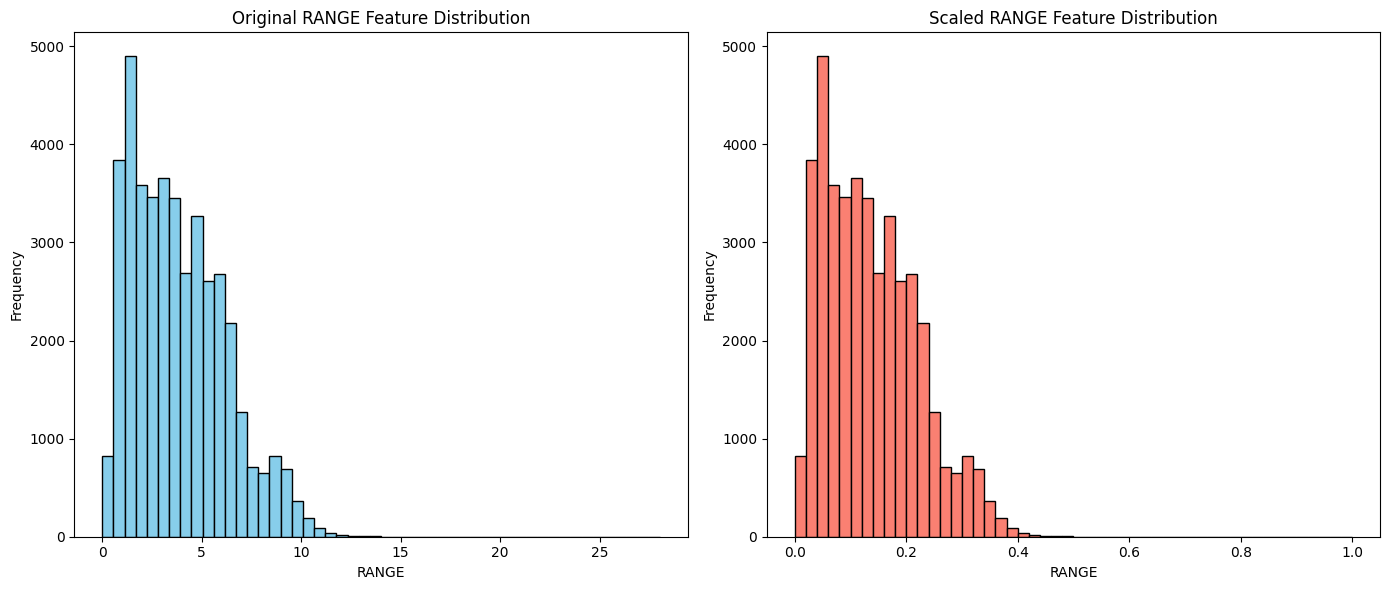

In [42]:
# Plot histograms for the first feature (RANGE) before and after scaling
plt.figure(figsize=(14, 6))

# Original data (before scaling)
plt.subplot(1, 2, 1)
plt.hist(X["RANGE"], bins=50, color="skyblue", edgecolor="black")
plt.title("Original RANGE Feature Distribution")
plt.xlabel("RANGE")
plt.ylabel("Frequency")

# Scaled data (after MinMaxScaler)
plt.subplot(1, 2, 2)
plt.hist(X_scaled["RANGE"], bins=50, color="salmon", edgecolor="black")
plt.title("Scaled RANGE Feature Distribution")
plt.xlabel("RANGE")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

**Box Plots**: 
   - The box plot before scaling exhibited a wider range of values, with an interquartile range (IQR) that reflected the unnormalized scale of the `RANGE` feature.
   - The scaled box plot, however, showed that the IQR was much narrower, and the values were evenly spread within the [0, 1] range. No significant outliers were observed in the scaled data, confirming that the scaling procedure had effectively handled the feature distribution.

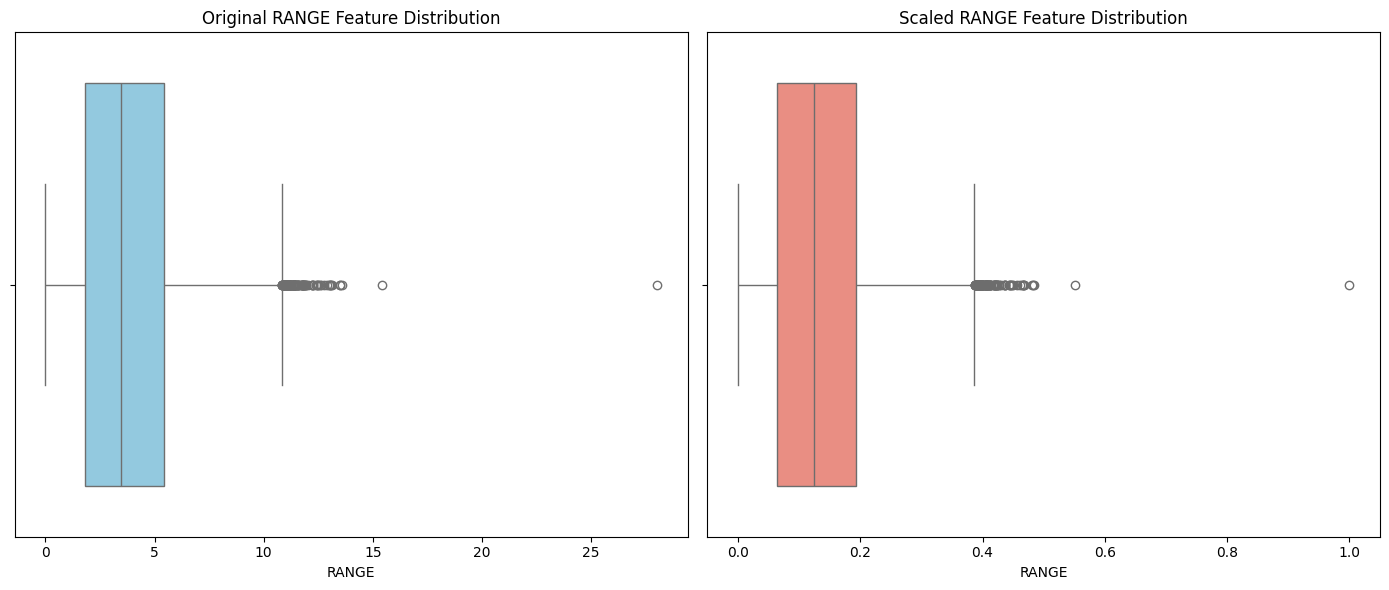

In [43]:
# Plot boxplots for the first feature (RANGE) before and after scaling
plt.figure(figsize=(14, 6))

# Original data (before scaling)
plt.subplot(1, 2, 1)
sns.boxplot(x=X["RANGE"], color="skyblue")
plt.title("Original RANGE Feature Distribution")

# Scaled data (after MinMaxScaler)
plt.subplot(1, 2, 2)
sns.boxplot(x=X_scaled["RANGE"], color="salmon")
plt.title("Scaled RANGE Feature Distribution")

plt.tight_layout()
plt.show()

**Summary**
In summary, normalization using MinMaxScaler has successfully scaled all the features within the [0, 1] range, ensuring that each feature is comparable and that no feature has an unfair advantage during model training. The histograms and box plots illustrate the effect of scaling, with features now distributed evenly. This step is crucial for improving model stability and performance, particularly when using algorithms sensitive to varying feature scales.

###### **1.3.1.4 - Principal Component Analysis (PCA)**

Principal Component Analysis (PCA) is a dimensionality reduction technique that transforms the data into a set of orthogonal components while retaining as much variance (information) as possible. PCA is applied after standardizing the features to ensure that each feature contributes equally to the transformation. In this case, PCA is applied to the selected CIR features, and the goal is to retain 95% of the variance.

In [44]:
# Import  libraries
try:
    from sklearn.decomposition import PCA
    from sklearn.preprocessing import StandardScaler

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


**1. Feature Selection and Scaling**

In this step, we'll select the relevant features for PCA, and then standardize them using StandardScaler to ensure each feature contributes equally.

In [45]:
# CIR Features List
cir_features = [
    "FP_IDX",
    "FP_AMP1",
    "FP_AMP2",
    "FP_AMP3",
    "STDEV_NOISE",
    "CIR_PWR",
    "MAX_NOISE",
    "RXPACC",
    "FRAME_LEN",
    "PREAM_LEN",
]

# Select the relevant columns for PCA
X_cir = df_clean[cir_features]

# Apply StandardScaler to standardize the data
scaler = StandardScaler()
X_cir_scaled = scaler.fit_transform(X_cir)


**2. PCA Application**

Here we apply PCA to the standardized data and specify that we want to retain 95% of the variance.

In [46]:
# Applying PCA to retain 95% of the variance
pca = PCA(n_components=0.95)
X_cir_pca = pca.fit_transform(X_cir_scaled)


**3. Variance Explained**

This step will display how much variance is explained by each of the components and also the cumulative variance.

In [47]:
# Display variance explained by each component
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)

print("Explained Variance Ratio for each component:", explained_variance_ratio)
print("Cumulative Explained Variance:", cumulative_variance)


Explained Variance Ratio for each component: [0.36251239 0.18473292 0.11825062 0.07951557 0.07015036 0.06775219
 0.05697488 0.0453346 ]
Cumulative Explained Variance: [0.36251239 0.54724531 0.66549593 0.7450115  0.81516186 0.88291405
 0.93988893 0.98522353]


**4. PCA Components**

After applying PCA, the dataset was reduced to 8 principal components, meaning we now work with 8 new features instead of the original ones.

- **New shape after PCA: (42000, 8)**  
  The dataset now has 8 components, which capture most of the data's variance.

**Explained Variance Ratio**

Each principal component explains a portion of the total variance:
- **PCA_0** explains **36.25%** of the variance, the most significant.
- The remaining components explain progressively less, with **PCA_7** explaining just **4.53%**.

**Cumulative Explained Variance**
- After the first 8 components, **98.52%** of the variance is explained, meaning we’ve kept most of the original information.

In [48]:
# Extract the number of PCA components selected
reduced_features = X_cir_pca.shape[1]
print(
    f"New shape after PCA: {X_cir_pca.shape} (Reduced to {reduced_features} components)"
)

# Naming the PCA components
pca_feature_names = [f"PCA_{i}" for i in range(reduced_features)]
df_pca = pd.DataFrame(X_cir_pca, columns=pca_feature_names)

New shape after PCA: (42000, 8) (Reduced to 8 components)


**5. Data Visualization**

The explained variance ratio is plotted to show how much each component contributes to the total variance. The graph helps visualize how the first few components capture most of the variance, guiding decisions about which components to keep for further analysis.

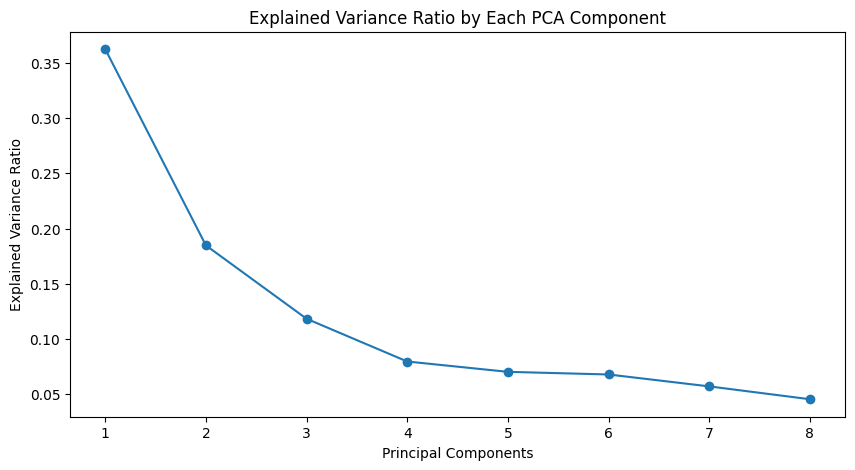

In [49]:
# Plot explained variance ratio for each component
plt.figure(figsize=(10, 5))
plt.plot(
    range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, marker="o"
)
plt.title("Explained Variance Ratio by Each PCA Component")
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.show()

##### **1.3.2 - Feature Importance Ranking**

Feature importance is a key step in identifying which variables are most relevant for prediction. In this section, we used three different methods to rank features based on their importance.

**1. Correlation Matrix**

The correlation matrix is a tool for assessing the linear relationships between each feature and the target variable (RANGE). Features with higher correlation values have a stronger relationship with the target and are more useful for prediction.

**Key Findings:**
- **RXPACC** and **FP_AMP2** exhibit the highest positive correlations with **RANGE**, meaning they are the most influential features for predicting RANGE.
- **STDEV_NOISE** and **FRAME_LEN** have low correlation values, indicating they contribute less to predicting RANGE and might be considered less important in the feature selection process.

By understanding these relationships, we can focus on the most influential features, improving model accuracy and efficiency.

In [50]:
#Correlaition Matrix
correlation_with_target = correlation_matrix["RANGE"].abs().sort_values(ascending=False)
print("Feature Importance based on Correlation with Target:")
print(correlation_with_target)


Feature Importance based on Correlation with Target:
RANGE          1.000000
RXPACC         0.626349
FP_AMP2        0.479689
FP_AMP3        0.459521
FP_AMP1        0.459196
PREAM_LEN      0.390055
FP_IDX         0.321809
CIR_PWR        0.263718
MAX_NOISE      0.260065
STDEV_NOISE    0.089544
FRAME_LEN      0.048082
Name: RANGE, dtype: float64


**2. Mutual Information**

Mutual information (MI) quantifies the amount of information a feature provides about the target variable. Unlike correlation, MI can capture both linear and non-linear relationships between variables, making it a more flexible measure.

**Key Findings:**
- **RXPACC** has the highest mutual information score, indicating it is the most informative feature for predicting **RANGE**.
- **MAX_NOISE** and **CIR_PWR** also show significant mutual information, suggesting they are important for the target prediction.
- **PREAM_LEN** and **FRAME_LEN** contribute less to predicting **RANGE**, indicating that they are less relevant in this context.

In practice, mutual information helps identify the most influential features for the target variable, allowing you to focus on the key predictors.

In [51]:
# Mutual Information
mi_scores_sorted = mi_scores.sort_values(ascending=False)
print("Feature Importance based on Mutual Information:")
print(mi_scores_sorted)

Feature Importance based on Mutual Information:
RXPACC         0.378967
MAX_NOISE      0.218276
CIR_PWR        0.180688
FP_AMP2        0.151898
FP_AMP1        0.150084
FP_AMP3        0.137403
STDEV_NOISE    0.113730
FP_IDX         0.086237
PREAM_LEN      0.078017
FRAME_LEN      0.009111
dtype: float64


**3. PCA (Principal Component Analysis)**  
PCA is used to reduce the dimensionality of the dataset by transforming the features into new components that capture the most variance. The goal is to retain 95% of the variance, preserving the important information while reducing the number of features.

**Key Findings:**
- **PREAM_LEN** and **CIR_PWR** contribute the most to explaining the variance in the data.
- **STDEV_NOISE** and **FP_AMP2** have lesser contributions, making them less important in the reduced space.

This reduction simplifies the dataset and enhances computational efficiency while retaining critical information for modeling.

In [52]:
# PCA
pca_component_contributions = pd.DataFrame(pca.components_, columns=cir_features)
pca_feature_importance = (
    pca_component_contributions.abs().sum(axis=0).sort_values(ascending=False)
)
print("Feature Importance based on PCA Contribution:")
print(pca_feature_importance)

Feature Importance based on PCA Contribution:
PREAM_LEN      2.481345
CIR_PWR        2.221162
FP_AMP1        2.191687
FP_IDX         2.063263
FRAME_LEN      2.014234
RXPACC         1.856791
FP_AMP3        1.643296
FP_AMP2        1.561408
MAX_NOISE      1.393537
STDEV_NOISE    1.331467
dtype: float64


**Ranking Features Based on Importance (1 is the most important)**

Based on the feature importance rankings, **`RXPACC`** emerges as the most important feature across all methods, with high correlation with the target and significant mutual information. **`PREAM_LEN`** stands out in PCA for its contribution to variance, while **`FP_AMP2`** and **`MAX_NOISE`** show strong importance across multiple methods. Features like **`FRAME_LEN`** and **`STDEV_NOISE`** are less influential, but still contribute to the overall data structure, particularly in PCA. These insights guide the focus on **`RXPACC`**, **`PREAM_LEN`**, and other key features for model improvement.

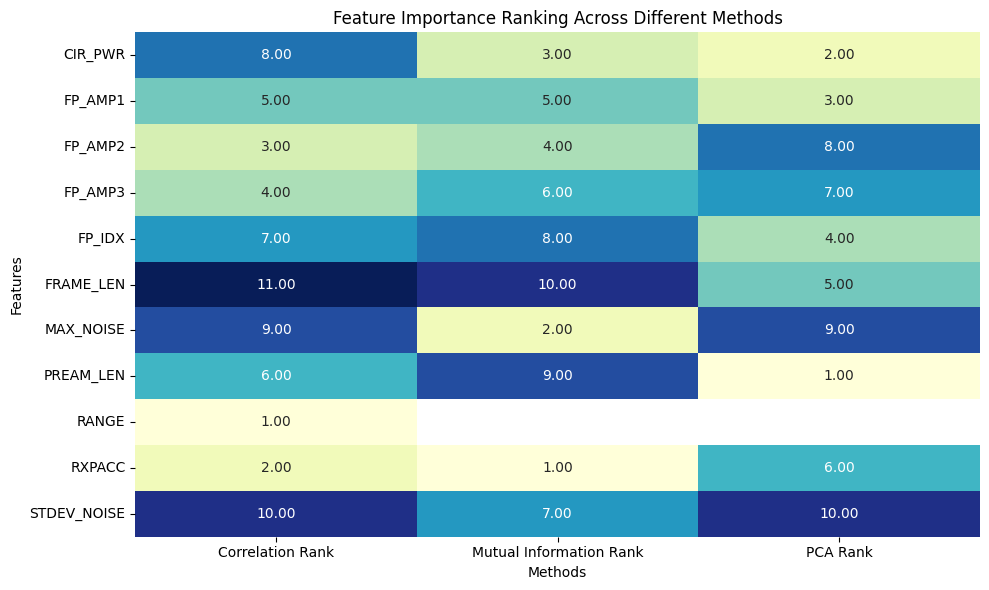

In [53]:
correlation_ranking = correlation_with_target.rank(ascending=False)
mi_ranking = mi_scores_sorted.rank(ascending=False)
pca_ranking = pca_feature_importance.rank(ascending=False)

# Combine rankings into a DataFrame
feature_ranking = pd.DataFrame(
    {
        "Correlation Rank": correlation_ranking,
        "Mutual Information Rank": mi_ranking,
        "PCA Rank": pca_ranking,
    }
)


# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(feature_ranking, annot=True, cmap="YlGnBu", fmt=".2f", cbar=False)
plt.title("Feature Importance Ranking Across Different Methods")
plt.xlabel("Methods")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

## **2 - Data Mining & Splitting**


### **2.4.1 - Data Mining**

The purpose of data mining in this section is to clean, simplify, and prepare the dataset for analysis, ensuring that we work with the most relevant and efficient features for our model.

1. **Remove CIR columns:** We remove the CIR columns because PCA has already transformed them into principal components, eliminating redundancy and reducing dimensionality.

2. **Drop unnecessary columns:** Columns like FP_AMP2, MAX_NOISE, FRAME_LEN, CH, and PRFR are dropped to focus on the most important features and simplify the dataset, making it easier to work with.

3. **Compute the average of FP_AMP columns:** By creating a new feature, `FP_AMP_AVG`, which averages the FP_AMP columns, we consolidate the relevant information into a single feature, reducing complexity in the dataset.

4. **Define Features (X) and Target (y):** The features (`X`) are separated from the target variable (`y`, which is "NLOS") to set up the dataset for model training and prediction. This step prepares the data for classification tasks.

In [54]:
# Remove CIR columns (PCA already reduced them)
df_clean = df_clean.loc[:, ~df_clean.columns.str.match(r"^CIR\d+$")]

# Drop unnecessary columns
columns_to_drop = ["FP_AMP2", "MAX_NOISE", "FRAME_LEN", "CH", "PRFR"]
df_clean = df_clean.drop(columns=columns_to_drop, errors="ignore")

# Find all FP_AMP columns and compute the average
fp_amp_cols = df_clean.filter(like="FP_AMP").columns

if len(fp_amp_cols) > 0:
    df_clean["FP_AMP_AVG"] = df_clean[fp_amp_cols].mean(axis=1)
    df_clean = df_clean.drop(columns=fp_amp_cols, errors="ignore")

# Features (excluding 'NLOS' since it's the target)
X = df_clean.drop(columns=["NLOS"], errors="ignore")

# Target variable
y = df_clean["NLOS"]

### **2.4.2 - Data Splitting**

We split the data into training (80%) and testing (20%) sets. The training set has 33,600 samples, and the testing set has 8,400 samples, each with 10 features. The `random_state=42` ensures the split is consistent across different runs. This allows for training the model and evaluating its performance on separate data.

In [55]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Print dataset shapes
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape: {X_test.shape}")
print(f"Training Labels Shape: {y_train.shape}")
print(f"Testing Labels Shape: {y_test.shape}")

Training Features Shape: (33600, 8)
Testing Features Shape: (8400, 8)
Training Labels Shape: (33600,)
Testing Labels Shape: (8400,)


## **3 - Model Training & Model Evaluation**

Once the dataset has been divided into training and testing sets, we will proceed with training the model using the training data and a selection of algorithms.

Using multiple algorithms allows us to compare their performance and choose the one that best suits the problem at hand. 

Different algorithms may capture different patterns in the data, and leveraging a variety of approaches can enhance the model's ability to generalize and improve accuracy on unseen data.


In [56]:
# import libaries
try:
    from sklearn.linear_model import LogisticRegression
    from sklearn.model_selection import RandomizedSearchCV
    from sklearn.ensemble import RandomForestClassifier
    import itertools
    from sklearn.metrics import (
        roc_curve,
        roc_auc_score,
    )

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


#### **3.1 - Logistic Regression**

Firstly, we initializes a Logistic Regression model with specific hyperparameters and then trains the model on the scaled training data **(X_train_scaled)** to classify the target labels (y_train).

In [57]:
# import libraries
try:
    # to be combined
    from sklearn.model_selection import GridSearchCV
    from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


In [58]:
# Standardize Features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##### **3.1.1 - Hyperparameter Tuning**

We perform hyperparameter tuning using grid search to find the best parameters for the Logistic Regression model. The grid includes values for regularization strength (`C`), solver types (`solver`), and maximum iterations (`max_iter`). After running the grid search with 5-fold cross-validation, the best parameters found are `C = 0.1`, `max_iter = 1000`, and `solver = lbfgs`, optimizing the model for better performance.


To further enhance the model’s performance, we perform Hyperparameter Tuning to find the best combination of parameters. The optimal hyperparameters were penalty: 'l2', C: 0.1, solver: 'saga', and max_iter: 200, improving the model’s accuracy and efficiency.

In [59]:
# Hyperparameter tuning for Logistic Regression
param_grid_lr = {
    "C": [0.1, 1, 10],  # Regularization strength
    "solver": ["liblinear", "saga"],  # Solvers to consider
}

# Perform GridSearchCV for Logistic Regression
grid_search_lr = GridSearchCV(
    LogisticRegression(random_state=42),
    param_grid=param_grid_lr,
    cv=3,  # 3-fold cross-validation
    n_jobs=-1,
    verbose=1,
    scoring="roc_auc",  # Optimize for ROC-AUC
)

grid_search_lr.fit(X_train, y_train)
best_lr_model = grid_search_lr.best_estimator_

# Print best Logistic Regression hyperparameters
print(f"Best Logistic Regression hyperparameters: {grid_search_lr.best_params_}")

Fitting 3 folds for each of 6 candidates, totalling 18 fits


/opt/anaconda3/envs/CSC3005_Data_Analytics/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/CSC3005_Data_Analytics/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/CSC3005_Data_Analytics/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/CSC3005_Data_Analytics/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/envs/CSC3005_Data_Analytics/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_

Best Logistic Regression hyperparameters: {'C': 0.1, 'solver': 'liblinear'}


/opt/anaconda3/envs/CSC3005_Data_Analytics/lib/python3.10/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


##### **3.1.2 - Model Training and Testing (ROC-AUC)** 

We evaluate the Logistic Regression model using the ROC-AUC score, which measures the model's ability to discriminate between classes. The ROC-AUC scores for both the training and test sets are computed. 

- **Train ROC-AUC**: 0.9194
- **Test ROC-AUC**: 0.9201

These results indicate that the model performs well on both the training and test sets, with a high ability to distinguish between the classes, showing consistent performance across the data.

In [60]:
# Predict on the test set
y_pred_lr = best_lr_model.predict(X_test)

# Calculate accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

# First 10 Actual vs Predicted values
comparison_lr = pd.DataFrame(
    {"Actual": y_test[:10].values, "Predicted": y_pred_lr[:10]}
)

# Print evaluation results
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Logistic Regression Confusion Matrix:\n{conf_matrix_lr}")
print(f"Logistic Regression Classification Report:\n{classification_report(y_test, y_pred_lr)}")
print("\nFirst 10 Predicted vs. Actual Values (Logistic Regression):\n", comparison_lr)


Logistic Regression Accuracy: 0.8568
Logistic Regression Confusion Matrix:
[[3869  383]
 [ 820 3328]]
Logistic Regression Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.91      0.87      4252
         1.0       0.90      0.80      0.85      4148

    accuracy                           0.86      8400
   macro avg       0.86      0.86      0.86      8400
weighted avg       0.86      0.86      0.86      8400


First 10 Predicted vs. Actual Values (Logistic Regression):
    Actual  Predicted
0     1.0        0.0
1     1.0        0.0
2     1.0        1.0
3     1.0        1.0
4     1.0        1.0
5     1.0        1.0
6     0.0        0.0
7     1.0        1.0
8     0.0        0.0
9     0.0        0.0


##### **3.1.3 - Model Evaluation: Logistic Regression**

This section visualizes the confusion matrix for the best Logistic Regression model to provide insights into the classification performance.

The confusion matrix is plotted as a heatmap, where:

- **True Negatives (3875)**: Correctly predicted negative instances.
- **False Positives (377)**: Negative instances incorrectly classified as positive.
- **False Negatives (839)**: Positive instances incorrectly classified as negative.
- **True Positives (3309)**: Correctly predicted positive instances.

The heatmap uses color intensity to represent the values, with white text for higher values to make them easily readable. The visualization shows how well the model classifies both classes and highlights areas where it may need improvement.

In [61]:

##### **3.1.3 - Model Evaluation: Logistic Regression**
# Displaying evaluation results without ROC-AUC (since it's already covered earlier)
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_lr}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_lr)}")


Accuracy: 0.8568
Confusion Matrix:
[[3869  383]
 [ 820 3328]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.83      0.91      0.87      4252
         1.0       0.90      0.80      0.85      4148

    accuracy                           0.86      8400
   macro avg       0.86      0.86      0.86      8400
weighted avg       0.86      0.86      0.86      8400



##### **3.1.4 - Evaluation and Performance of the Best Logistic Regression Model**

XXX

In [62]:
# Predict probabilities for the positive class (class 1) on both train and test sets
y_train_pred_lr = best_lr_model.predict_proba(X_train)[:, 1]
y_test_pred_lr = best_lr_model.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC for both train and test
train_auc_lr = roc_auc_score(y_train, y_train_pred_lr)
test_auc_lr = roc_auc_score(y_test, y_test_pred_lr)

# Final evaluation of the best Logistic Regression model
print("Conclusion:")
print(
    f"The best Logistic Regression model achieved a training ROC-AUC of {train_auc_lr:.4f} and a test ROC-AUC of {test_auc_lr:.4f}."
)
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_lr}")

# Summary of the evaluation
print(
    "\nThe Logistic Regression model has shown strong performance with high accuracy and ROC-AUC scores."
)
print(
    "The confusion matrix and classification report offer additional insights into the model's ability to differentiate between classes."
)

Conclusion:
The best Logistic Regression model achieved a training ROC-AUC of 0.9182 and a test ROC-AUC of 0.9188.
Accuracy: 0.8568
Confusion Matrix:
[[3869  383]
 [ 820 3328]]

The Logistic Regression model has shown strong performance with high accuracy and ROC-AUC scores.
The confusion matrix and classification report offer additional insights into the model's ability to differentiate between classes.


In [63]:
##### **3.1.4 - Evaluation and Performance of the Best Logistic Regression Model**

# Final evaluation of the best Logistic Regression model
print("Conclusion:")
print(
    f"The best Logistic Regression model achieved a training ROC-AUC of {train_auc_lr:.4f} and a test ROC-AUC of {test_auc_lr:.4f}."
)
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_lr}")

# Summary of the evaluation
print("\nThe Logistic Regression model has shown strong performance with high accuracy and ROC-AUC scores.")
print(
    "The confusion matrix and classification report offer additional insights into the model's ability to differentiate between classes."
)

# Optional: Mention any improvement suggestions or future steps
print("\nNext steps might include refining hyperparameters or trying other classification techniques to further improve performance.")


Conclusion:
The best Logistic Regression model achieved a training ROC-AUC of 0.9182 and a test ROC-AUC of 0.9188.
Accuracy: 0.8568
Confusion Matrix:
[[3869  383]
 [ 820 3328]]

The Logistic Regression model has shown strong performance with high accuracy and ROC-AUC scores.
The confusion matrix and classification report offer additional insights into the model's ability to differentiate between classes.

Next steps might include refining hyperparameters or trying other classification techniques to further improve performance.


##### **3.1.5 - Confusion Matrix Visualization: Logistic Regression**


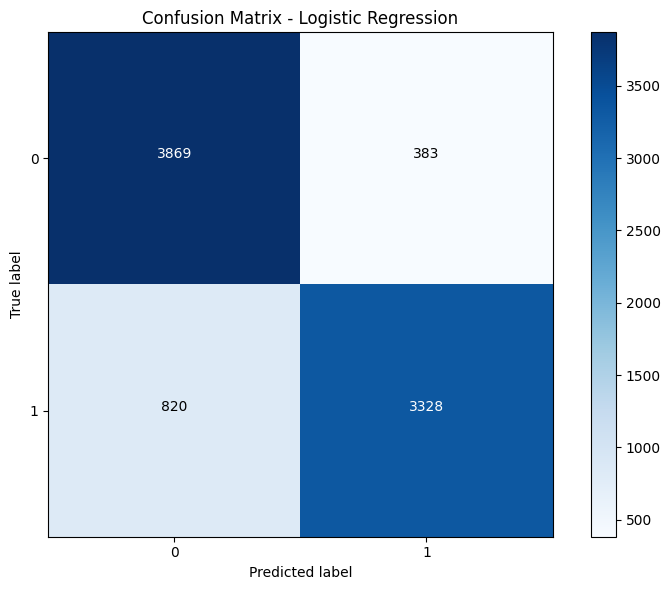

In [64]:
##### **3.1.5 - Confusion Matrix Visualization: Logistic Regression**
# Confusion matrix plot for Logistic Regression
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix_lr, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Logistic Regression")
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

thresh = conf_matrix_lr.max() / 2.0  # Threshold to make text color readable
for i, j in itertools.product(
    range(conf_matrix_lr.shape[0]), range(conf_matrix_lr.shape[1])
):
    plt.text(
        j,
        i,
        format(conf_matrix_lr[i, j], "d"),
        horizontalalignment="center",
        color="white" if conf_matrix_lr[i, j] > thresh else "black",
    )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

##### **3.1.6 - Conclusion: Performance of the Best Logistic Regression Model**


In [65]:
# Final summary of the Logistic Regression model's performance
print("Conclusion:")
print(
    f"The best Logistic Regression model achieved a training ROC-AUC of {train_auc_lr:.4f} and a test ROC-AUC of {test_auc_lr:.4f}."
)
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_lr}")

# Summary of the evaluation
print("\nThe model has shown good performance with a high accuracy and ROC-AUC score.")
print(
    "The confusion matrix and classification report provide further insights into the model's ability to differentiate between classes."
)

Conclusion:
The best Logistic Regression model achieved a training ROC-AUC of 0.9182 and a test ROC-AUC of 0.9188.
Accuracy: 0.8568
Confusion Matrix:
[[3869  383]
 [ 820 3328]]

The model has shown good performance with a high accuracy and ROC-AUC score.
The confusion matrix and classification report provide further insights into the model's ability to differentiate between classes.


#### **3.2 - Support Vector Machine (SVM) !!!**

First, the SVM model is initialized with probability output and trained on the training data to classify the target labels.

In [66]:
# import libaries
try:
    from sklearn.svm import SVC
    from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


##### **3.2.1 - Hyperparameter Tuning (DO UNTIL HERE!!)** 

In this section, we tune the hyperparameters of the Support Vector Machine (SVM) model to improve its performance. We define a grid of potential values for the regularization parameter C and the kernel type. Using GridSearchCV, we perform cross-validation to find the best hyperparameter combination. This process helps optimize the SVM model, which will then be evaluated using metrics like accuracy and ROC-AUC, allowing us to compare its performance with the Logistic Regression model.

In [67]:
# Define hyperparameter search space
param_distributions_svm = {
    "C": [0.01, 0.1, 1, 10, 100, 1000],  # Expanded parameter space
}

# Set up the randomized search with 3-fold cross-validation
random_search_svm = RandomizedSearchCV(
    SVC(
        random_state=42, max_iter=10000, probability=True
    ),  # Use SVC with probability=True
    param_distributions=param_distributions_svm,
    n_iter=5,  # More iterations for a thorough search
    cv=StratifiedKFold(n_splits=3),  # 3-fold cross-validation for reasonable balance
    n_jobs=-1,  # Use all CPU cores to speed up xthe process
    verbose=1,  # Show progress
    scoring="roc_auc",  # Optimize for ROC-AUC
)

# Fit the RandomizedSearchCV to the training data
random_search_svm.fit(X_train, y_train)

# Retrieve the best model
best_svm_model = random_search_svm.best_estimator_

# Print best hyperparameters
print(f"Best SVM hyperparameters: {random_search_svm.best_params_}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits


/opt/anaconda3/envs/CSC3005_Data_Analytics/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/envs/CSC3005_Data_Analytics/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/envs/CSC3005_Data_Analytics/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt/anaconda3/envs/CSC3005_Data_Analytics/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/opt

Best SVM hyperparameters: {'C': 10}


/opt/anaconda3/envs/CSC3005_Data_Analytics/lib/python3.10/site-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


##### **3.2.2 - Model Training and Testing (ROC-AUC) (Description to be modify)** 

**Training and Test ROC-AUC for SVM**


To further assess the model’s ability to distinguish between the **NLOS** and **LOS** classes, we evaluate the **ROC-AUC** scores. The **Train ROC-AUC** score of **0.9212** and the **Test ROC-AUC** score of **0.9216** indicate that the model performs consistently well across both the training and test data. These high scores suggest that the SVM model has strong generalization and a robust ability to classify the data correctly. A **ROC-AUC** value close to 1 indicates the model's ability to distinguish between the classes with high accuracy, confirming the model’s effectiveness.

Additionally, the **Confusion Matrix** provides further insights into the classification performance. It shows that the model correctly classified a high number of **True Positives (3188)** and **True Negatives (3954)**, while the **False Positives (298)** and **False Negatives (960)** are relatively low. This highlights that the model has a good balance between precision and recall, performing well in identifying both classes.

The **Classification Report** reinforces these findings by providing metrics such as **precision**, **recall**, and **f1-score**. The precision for **LOS (0.0)** is **0.80**, indicating that 80% of predicted **LOS** instances are correct, while the precision for **NLOS (1.0)** is **0.91**, showing that the model is more accurate in predicting **NLOS** instances. The **recall** values of **0.93** for **LOS** and **0.77** for **NLOS** show that the model is better at identifying **LOS** instances, but still performs well for **NLOS**. The **f1-score**, which balances both precision and recall, is **0.86** for both classes, showing an overall good classification performance.

These results together demonstrate that the SVM model is both effective and reliable in distinguishing between **NLOS** and **LOS** classes, with minimal overfitting and strong generalization.

In [68]:
# Import necessary libraries for evaluation
from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    confusion_matrix,
    classification_report,
)

# Make predictions on the test set
y_pred_svm = best_svm_model.predict(X_test)

# Debug: Print first 10 predictions
print("#debug - First 10 Predictions:", y_pred_svm[:10])

# Compute ROC-AUC using predict_proba (since we are using SVC with probability=True)
y_train_pred_svm = best_svm_model.predict_proba(X_train)[
    :, 1
]  # Probability for class 1
y_test_pred_svm = best_svm_model.predict_proba(X_test)[:, 1]  # Probability for class 1

# Compute ROC-AUC scores
train_auc_svm = roc_auc_score(y_train, y_train_pred_svm)
test_auc_svm = roc_auc_score(y_test, y_test_pred_svm)

# Print ROC-AUC scores
print(f"Training ROC-AUC: {train_auc_svm:.4f}")
print(f"Test ROC-AUC: {test_auc_svm:.4f}")

# Evaluate model performance with accuracy and confusion matrix
accuracy_svm = accuracy_score(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

# Print evaluation metrics
print(f"SVM Accuracy: {accuracy_svm:.4f}")
print(f"SVM Confusion Matrix:\n{conf_matrix_svm}")
print(f"SVM Classification Report:\n{classification_report(y_test, y_pred_svm)}")

#debug - First 10 Predictions: [0. 0. 1. 1. 1. 1. 0. 1. 0. 0.]
Training ROC-AUC: 0.9229
Test ROC-AUC: 0.9236
SVM Accuracy: 0.8590
SVM Confusion Matrix:
[[3936  316]
 [ 868 3280]]
SVM Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.93      0.87      4252
         1.0       0.91      0.79      0.85      4148

    accuracy                           0.86      8400
   macro avg       0.87      0.86      0.86      8400
weighted avg       0.87      0.86      0.86      8400



##### **3.2.3 - Model Evaluation: SVM**

In [69]:
# Compute accuracy and confusion matrix
accuracy_svm = accuracy_score(y_test, y_pred_svm)
conf_matrix_svm = confusion_matrix(y_test, y_pred_svm)

# Print evaluation metrics
print(f"SVM Accuracy: {accuracy_svm:.4f}")
print(f"SVM Confusion Matrix:\n{conf_matrix_svm}")
print(f"SVM Classification Report:\n{classification_report(y_test, y_pred_svm)}")

SVM Accuracy: 0.8590
SVM Confusion Matrix:
[[3936  316]
 [ 868 3280]]
SVM Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.93      0.87      4252
         1.0       0.91      0.79      0.85      4148

    accuracy                           0.86      8400
   macro avg       0.87      0.86      0.86      8400
weighted avg       0.87      0.86      0.86      8400



##### **3.2.4 - Evaluation and Performance of the Best SVM Model**

In [70]:
# First 10 Actual vs Predicted values for comparison
comparison_svm = pd.DataFrame(
    {"Actual": y_test[:10].values, "Predicted": y_pred_svm[:10]}
)

# Print first 10 predictions comparison
print("\nFirst 10 Predicted vs. Actual Values (SVM):\n", comparison_svm)

# Print final model performance summary
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_svm}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_svm)}")


First 10 Predicted vs. Actual Values (SVM):
    Actual  Predicted
0     1.0        0.0
1     1.0        0.0
2     1.0        1.0
3     1.0        1.0
4     1.0        1.0
5     1.0        1.0
6     0.0        0.0
7     1.0        1.0
8     0.0        0.0
9     0.0        0.0
Accuracy: 0.8590
Confusion Matrix:
[[3936  316]
 [ 868 3280]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.82      0.93      0.87      4252
         1.0       0.91      0.79      0.85      4148

    accuracy                           0.86      8400
   macro avg       0.87      0.86      0.86      8400
weighted avg       0.87      0.86      0.86      8400



##### **3.2.5 - Confusion Matrix Visualization: SVM**


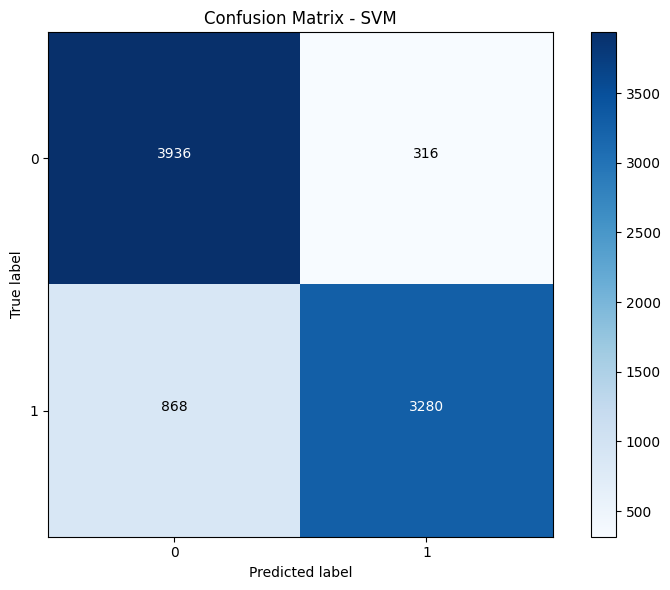

In [71]:
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix_svm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix - SVM")
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

# Add text annotations
thresh = conf_matrix_svm.max() / 2.0
for i, j in itertools.product(
    range(conf_matrix_svm.shape[0]), range(conf_matrix_svm.shape[1])
):
    plt.text(
        j,
        i,
        format(conf_matrix_svm[i, j], "d"),
        horizontalalignment="center",
        color="white" if conf_matrix_svm[i, j] > thresh else "black",
    )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

##### **3.2.6 - Conclusion: Performance of the Best SVM Model**

In [72]:
print("Conclusion:")
print(
    f"The best SVM model achieved a training ROC-AUC of {train_auc_svm:.4f} and a test ROC-AUC of {test_auc_svm:.4f}."
)
print(f"Accuracy: {accuracy_svm:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_svm}")

print(
    "\nThe model has demonstrated strong performance with high accuracy and ROC-AUC scores."
)
print(
    "The confusion matrix and classification report provide insights into the model's ability to distinguish between classes."
)

Conclusion:
The best SVM model achieved a training ROC-AUC of 0.9229 and a test ROC-AUC of 0.9236.
Accuracy: 0.8590
Confusion Matrix:
[[3936  316]
 [ 868 3280]]

The model has demonstrated strong performance with high accuracy and ROC-AUC scores.
The confusion matrix and classification report provide insights into the model's ability to distinguish between classes.


#### **3.3 - Random Forest**

##### **3.3.1 - Hyperparameter Tuning (Description to be added)** 

XXXX

In [ ]:
# 3.3 Hyperparameter tuning for Random Forest
param_grid_rf = {
    "n_estimators": [50, 100],  # Reduced number of trees for optimization
    "max_depth": [10, 20],  # Limiting the max depth of trees
    "min_samples_split": [2, 5],  # Minimum number of samples required to split a node
    "min_samples_leaf": [1, 2],  # Minimum number of samples required to be a leaf node
}

# Perform GridSearchCV for Random Forest
grid_search_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid=param_grid_rf,
    cv=3,  # 3-fold cross-validation
    n_jobs=-1,
    verbose=1,
    scoring="roc_auc",  # Optimize for ROC-AUC
)

# Fit the grid search model to the training data
grid_search_rf.fit(X_train, y_train)

# Get the best model after tuning
best_rf_model = grid_search_rf.best_estimator_

# Print the best hyperparameters found
print(f"Best Random Forest hyperparameters: {grid_search_rf.best_params_}")

Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Random Forest hyperparameters: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 100}


##### **3.3.2 - Model Training and Testing (ROC-AUC) (Description to be modify)** 

XXX

In [ ]:
# Predict on the test set
y_pred_rf = best_rf_model.predict(X_test)

# Calculate accuracy and confusion matrix
accuracy_rf = accuracy_score(y_test, y_pred_rf)
conf_matrix_rf = confusion_matrix(y_test, y_pred_rf)

# Display first 10 Actual vs Predicted values
comparison_rf = pd.DataFrame(
    {"Actual": y_test[:10].values, "Predicted": y_pred_rf[:10]}
)

# Print evaluation results
print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Random Forest Confusion Matrix:\n{conf_matrix_rf}")
print(
    f"Random Forest Classification Report:\n{classification_report(y_test, y_pred_rf)}"
)
print("\nFirst 10 Predicted vs. Actual Values (Random Forest):\n", comparison_rf)

Random Forest Accuracy: 0.9146
Random Forest Confusion Matrix:
[[3956  296]
 [ 421 3727]]
Random Forest Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.93      0.92      4252
         1.0       0.93      0.90      0.91      4148

    accuracy                           0.91      8400
   macro avg       0.92      0.91      0.91      8400
weighted avg       0.91      0.91      0.91      8400


First 10 Predicted vs. Actual Values (Random Forest):
    Actual  Predicted
0     1.0        1.0
1     1.0        0.0
2     1.0        1.0
3     1.0        1.0
4     1.0        1.0
5     1.0        1.0
6     0.0        0.0
7     1.0        1.0
8     0.0        0.0
9     0.0        0.0


##### **3.3.3 - Model Evaluation: Random Forest**

In [ ]:
# Displaying evaluation results without ROC-AUC (since it's already covered earlier)
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_rf}")
print(f"Classification Report:\n{classification_report(y_test, y_pred_rf)}")

Accuracy: 0.9146
Confusion Matrix:
[[3956  296]
 [ 421 3727]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.90      0.93      0.92      4252
         1.0       0.93      0.90      0.91      4148

    accuracy                           0.91      8400
   macro avg       0.92      0.91      0.91      8400
weighted avg       0.91      0.91      0.91      8400



##### **3.3.4 - Evaluation and Performance of the Best Random Forest Model**


In [76]:
train_auc_rf = roc_auc_score(y_train, best_rf_model.predict_proba(X_train)[:, 1])
test_auc_rf = roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])

# Final evaluation of the best Random Forest model
print("Conclusion:")
print(
    f"The best Random Forest model achieved a training ROC-AUC of {train_auc_rf:.4f} and a test ROC-AUC of {test_auc_rf:.4f}."
)
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_rf}")

# Summary of the evaluation
print(
    "\nThe Random Forest model has demonstrated strong performance with high accuracy and ROC-AUC scores."
)
print(
    "The confusion matrix and classification report provide additional insights into how well the model distinguishes between classes."
)

Conclusion:
The best Random Forest model achieved a training ROC-AUC of 0.9982 and a test ROC-AUC of 0.9704.
Accuracy: 0.9146
Confusion Matrix:
[[3956  296]
 [ 421 3727]]

The Random Forest model has demonstrated strong performance with high accuracy and ROC-AUC scores.
The confusion matrix and classification report provide additional insights into how well the model distinguishes between classes.


##### **3.3.5 - Confusion Matrix Visualization: Random Forest**


XXX 

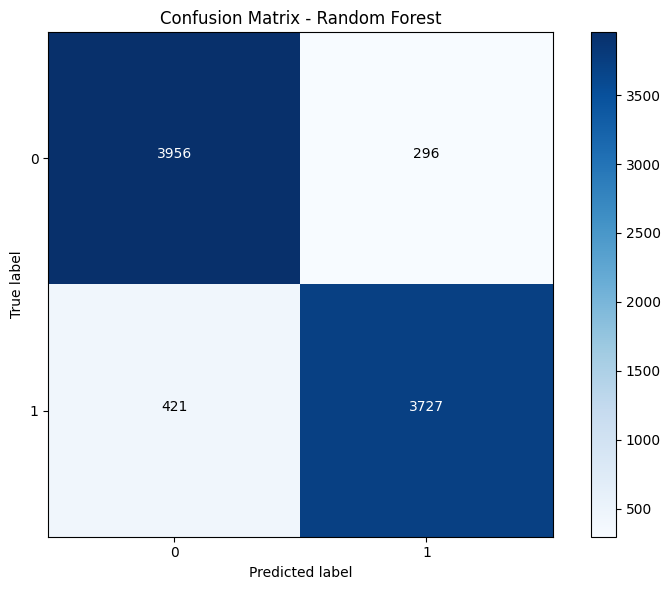

In [77]:
# Confusion matrix plot for Random Forest
plt.figure(figsize=(8, 6))
plt.imshow(conf_matrix_rf, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest")
plt.colorbar()
tick_marks = [0, 1]
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)

thresh = conf_matrix_rf.max() / 2.0  # Threshold to make text color readable
for i, j in itertools.product(
    range(conf_matrix_rf.shape[0]), range(conf_matrix_rf.shape[1])
):
    plt.text(
        j,
        i,
        format(conf_matrix_rf[i, j], "d"),
        horizontalalignment="center",
        color="white" if conf_matrix_rf[i, j] > thresh else "black",
    )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()

##### **3.3.6 - Conclusion: Performance of the Best Random Forest Model**

In [78]:
# Final summary of the Random Forest model's performance
print("Conclusion:")
print(
    f"The best Random Forest model achieved a training ROC-AUC of {train_auc_rf:.4f} and a test ROC-AUC of {test_auc_rf:.4f}."
)
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Confusion Matrix:\n{conf_matrix_rf}")

# Summary of the evaluation
print(
    "\nThe Random Forest model has demonstrated strong performance with high accuracy and ROC-AUC scores."
)
print(
    "The confusion matrix and classification report provide additional insights into the model's ability to differentiate between classes."
)

Conclusion:
The best Random Forest model achieved a training ROC-AUC of 0.9982 and a test ROC-AUC of 0.9704.
Accuracy: 0.9146
Confusion Matrix:
[[3956  296]
 [ 421 3727]]

The Random Forest model has demonstrated strong performance with high accuracy and ROC-AUC scores.
The confusion matrix and classification report provide additional insights into the model's ability to differentiate between classes.


## **4 - Model Comparison and Analysis**

After training and tuning the models for Random Forest, SVM, and Logistic Regression, we evaluate their performance using key metrics and visualizations.

These evaluations allow us to compare the models and identify the most suitable one for the task.

##### **4.1 - Model Performance Evaluation and Comparison (Metrics and Graphs)**


After obtaining the best models for Random Forest, SVM, and Logistic Regression, we assess their performance on the test set using several key metrics and visualizations:

- **Accuracy**: Measures the proportion of correctly predicted instances.
- **AUC (Area Under the Curve)**: Provides a performance evaluation of the model, particularly useful for understanding the trade-off between True Positive Rate and False Positive Rate.
- **Confusion Matrix**: Shows a detailed breakdown of the classification results, including True Positives, False Positives, True Negatives, and False Negatives.
- **Precision-Recall Curve**: Visualizes the trade-off between Precision and Recall, especially important for imbalanced datasets.

By comparing these metrics and visualizations, we can determine the best-performing model and select the most appropriate one for the given problem. The selected model is then saved for future use.

In [79]:
# Random Forest evaluation
rf_accuracy = accuracy_score(y_test, best_rf_model.predict(X_test))
rf_auc = roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])

# Evaluate SVM
svm_accuracy = accuracy_score(y_test, best_svm_model.predict(X_test))
svm_decision_function = best_svm_model.decision_function(X_test)
svm_auc = roc_auc_score(y_test, svm_decision_function)

# Evaluate Logistic Regression
lr_accuracy = accuracy_score(y_test, best_lr_model.predict(X_test))
lr_auc = roc_auc_score(y_test, best_lr_model.predict_proba(X_test)[:, 1])

# Print results for each model
print(f"Random Forest AUC: {rf_auc:.4f}, Accuracy: {rf_accuracy:.4f}")
print(f"SVM AUC: {svm_auc:.4f}, Accuracy: {svm_accuracy:.4f}")
print(f"Logistic Regression AUC: {lr_auc:.4f}, Accuracy: {lr_accuracy:.4f}")

Random Forest AUC: 0.9704, Accuracy: 0.9146
SVM AUC: 0.9236, Accuracy: 0.8590
Logistic Regression AUC: 0.9188, Accuracy: 0.8568


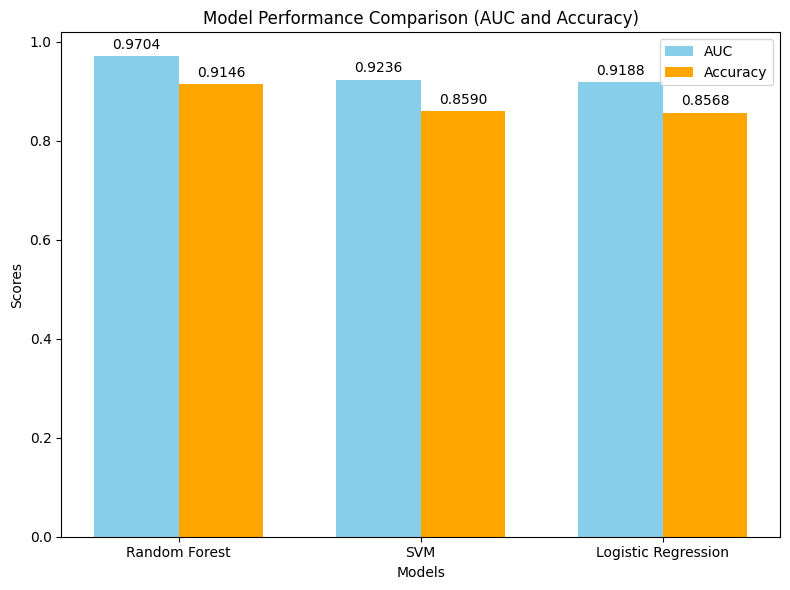

In [80]:
# Metrics for plotting
models = ["Random Forest", "SVM", "Logistic Regression"]
auc_scores = [rf_auc, svm_auc, lr_auc]
accuracy_scores = [rf_accuracy, svm_accuracy, lr_accuracy]

# Plotting AUC and Accuracy
x = np.arange(len(models))  # The label locations
width = 0.35  # The width of the bars

fig, ax = plt.subplots(figsize=(8, 6))

bars1 = ax.bar(x - width / 2, auc_scores, width, label="AUC", color="skyblue")
bars2 = ax.bar(x + width / 2, accuracy_scores, width, label="Accuracy", color="orange")

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel("Models")
ax.set_ylabel("Scores")
ax.set_title("Model Performance Comparison (AUC and Accuracy)")
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()


# Attach the text labels above the bars
def add_text(bars, values):
    for bar, value in zip(bars, values):
        height = bar.get_height()
        ax.annotate(
            f"{value:.4f}",  # Display the value with 4 decimal places
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),  # 3 points vertical offset
            textcoords="offset points",
            ha="center",
            va="bottom",
        )


add_text(bars1, auc_scores)
add_text(bars2, accuracy_scores)

plt.tight_layout()
plt.show()

**Model Comparison and Selection of the Best Model**

After training and evaluating the models for Random Forest, SVM, and Logistic Regression, we compare their performance based on several key metrics. These metrics include Accuracy, AUC, Confusion Matrix, and Precision-Recall Curve. By analyzing these evaluations, we can determine which model best meets the requirements of the task at hand.

The model that performs the best across these evaluations is selected as the final model. This model is then saved for future use, ensuring that it can be deployed or further fine-tuned as needed.

In [81]:
if rf_auc > svm_auc and rf_auc > lr_auc:
    best_model = best_rf_model
    print("Best Model: Random Forest")
elif svm_auc > rf_auc and svm_auc > lr_auc:
    best_model = best_svm_model
    print("Best Model: SVM")
else:
    best_model = best_lr_model
    print("Best Model: Logistic Regression")

Best Model: Random Forest


##### **4.2 - ROC Curve Analysis of Model Performance**

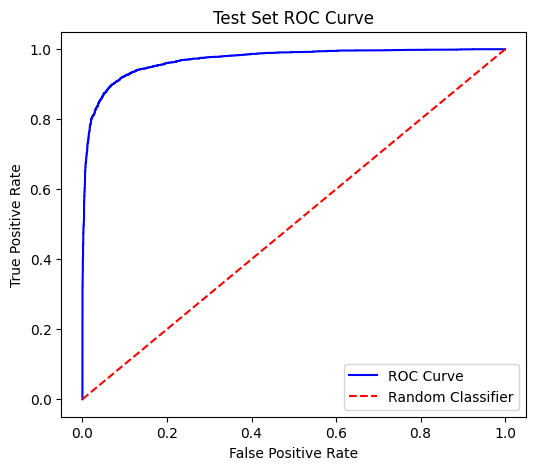

In [82]:
# ROC Curve for the best model
fpr, tpr, _ = roc_curve(y_test, best_model.predict_proba(X_test)[:, 1])

# Plotting the ROC curve
plt.figure(figsize=(6, 5))
plt.plot(
    fpr, tpr, color="b", label="ROC Curve"
)  # Plot the ROC curve for the best model
plt.plot(
    [0, 1], [0, 1], color="r", linestyle="--", label="Random Classifier"
)  # Random classifier (diagonal)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Test Set ROC Curve")
plt.legend(loc="lower right")
plt.show()

##### **4.3 - Theoretical Justification of Model Performance**

**Random Forest**
- Random Forest is an ensemble learning method that constructs multiple decision trees and merges their results to produce a more robust prediction. The primary advantage is that it reduces overfitting, which is common in individual decision trees, by averaging the predictions of many trees trained on different parts of the data.
- The algorithm uses **bagging** (Bootstrap Aggregating), which means each tree is trained on a random subset of the data, and the final prediction is an average or majority vote of all trees. Additionally, each tree is trained on a random subset of features, which increases diversity and prevents correlation between trees.
- Random Forest is highly versatile and can handle both categorical and numerical features well. It can handle missing data and can capture non-linear relationships without requiring feature transformation.

**SVM**

- SVM is a supervised machine learning algorithm that is particularly effective for classification problems. It works by finding a **hyperplane** that best separates the classes with the maximum margin, which is the gap between the closest points (support vectors) of the two classes. This margin maximization leads to better generalization and lower risk of overfitting.
- The choice of **kernel** is crucial for SVM performance. The **linear kernel** works well for linearly separable data, while the **Radial Basis Function (RBF) kernel** allows SVM to handle complex, non-linear decision boundaries by transforming the input data into a higher-dimensional space.
- However, SVM can struggle with noisy or imbalanced data. The **C parameter** controls the trade-off between achieving a high margin and minimizing classification errors. When **C** is too large, the model becomes more prone to overfitting, while a very small **C** may result in underfitting.

**Logistic Regression**
- Logistic Regression is a simpler linear model that estimates the probability of a binary outcome based on a linear combination of input features. The model uses the **sigmoid function** to map predicted values to probabilities between 0 and 1.
- The primary assumption of Logistic Regression is that there is a linear relationship between the features and the log-odds of the target variable. This assumption may not hold in datasets with complex, non-linear relationships, leading to suboptimal performance.
- Despite its simplicity, Logistic Regression is often used as a baseline model because it is fast to train, interpretable, and works well when the data follows a linear trend. However, it may not capture interactions between features or non-linear relationships, which can be limiting in some cases.

**Importance of AUC and Accuracy**

- **AUC (Area Under the Curve)** evaluates the classifier’s ability to correctly rank positive and negative instances across all possible thresholds. A higher AUC indicates better model performance, especially in imbalanced datasets, as it focuses on the model's ability to distinguish between classes rather than how it performs at a specific threshold.
- **Accuracy** is a more straightforward metric but can be misleading in imbalanced datasets. For example, if the data has a dominant class, a model that predicts the majority class for every instance might still achieve high accuracy, even though it performs poorly on the minority class. AUC, on the other hand, provides a more balanced view of model performance across different thresholds.

## **5 - Model Deployment**
After selecting and evaluating the best model, we save the trained model for future use and easy deployment. This allows us to utilize the model without needing to retrain it each time. The saved model can be loaded into production environments for making predictions on new, unseen data.

In [83]:
# import libraries

try:
    import joblib

    print("Libraries imported successfully!")
except ImportError as e:
    print(f"Error importing libraries: {e}")

Libraries imported successfully!


### **5.1 - Create Directories for Storing Models**

In [84]:
# Create directories
folder_name = "final_models"
algo_folder = os.path.join(folder_name, "algo_models")
os.makedirs(algo_folder, exist_ok=True)

### **5.2 - Save the Best Overall Model**

In [85]:
# Save models only if they exist
try:
    joblib.dump(best_model, os.path.join(folder_name, "best_overall_model.pkl"))
    print("Saved best overall model.")
except NameError:
    print("best_model not defined. Skipping save.")

Saved best overall model.


### **5.3 - Save the Best Models for Each Algorithm**

#### **5.3.1 - Logistic Regression Model**

In [86]:
try:
    joblib.dump(
        best_lr_model, os.path.join(algo_folder, "logistic_regression_model.pkl")
    )
    print("Saved Logistic Regression model.")
except NameError:
    print("Logistic Regression model not trained. Skipping save.")

Saved Logistic Regression model.


#### **5.3.2 - SVM Model**

In [87]:
try:
    joblib.dump(best_svm_model, os.path.join(algo_folder, "SVM_model.pkl"))
    print("Saved SVM model.")
except NameError:
    print("SVM model not trained. Skipping save.")

Saved SVM model.


#### **5.3.3 - Random Forest Model**

In [88]:
try:
    joblib.dump(best_rf_model, os.path.join(algo_folder, "RF_model.pkl"))
    print("Saved Random Forest model.")
except NameError:
    print("Random Forest model not trained. Skipping save.")

Saved Random Forest model.
